# **Heart Disease Exploratory Data Analysis**

**Author name:** Tushar Chouhan

**Date:** 1 May 2026

## **Introduction**

This notebook presents a structured exploratory data analysis of a heart disease dataset. 
It focuses on understanding variable distributions and relationships relevant to heart disease prediction.


## **Objectives**

Here are the objectives.

* Understand the composition and distribution of the data
* Identify patterns and relationships between variables in data set
* Explore factors influencing the heart disease
* Provide actionable insights for heart disease management
* Create publication-ready visualizations


**Let's get started**

# **1. Import Libraries**

In [27]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

In [28]:
# Set up matplotlib for high-resolution plots
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.style.use('seaborn-v0_8-whitegrid')
# Set seaborn style
sns.set_palette("Set2")
sns.set_style("whitegrid")

# **2. Import Dataset**

In [29]:
df = pd.read_csv("../data/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


# **3. Dataset Overview**

In [30]:
 #📋 Basic Information about the Dataset
print("="*60)
print("DATASET OVERVIEW")
print("="*60)

# Display first 5 rows
print("\n🔍 First 5 rows of the dataset:")
display(df.head())

# Dataset info
print("\n📊 Dataset Information:")
print(f"Number of records: {df.shape[0]:,}")
print(f"Number of features: {df.shape[1]}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Data types and missing values
print("\n Data Types and Missing Values:")
info_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique Values': df.nunique()
})
display(info_df)

DATASET OVERVIEW

🔍 First 5 rows of the dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



📊 Dataset Information:
Number of records: 303
Number of features: 14
Memory usage: 0.03 MB

📝 Data Types and Missing Values:


,Data Type,Missing Values,Missing %,Unique Values
age,float64,0,0.00,41
sex,float64,0,0.00,2
cp,float64,0,0.00,4
trestbps,float64,0,0.00,50
chol,float64,0,0.00,152
fbs,float64,0,0.00,2
restecg,float64,0,0.00,3
thalach,float64,0,0.00,91
exang,float64,0,0.00,2
oldpeak,float64,0,0.00,40


**Interpretation:**

The dataset contains 303 patients' data with 14 features. There are no missing values, which is excellent for analysis. We have 9 categorical variables (sex, cp, fbs, restecg, exang, slope, ca, thal, and target) and 5 numerical variables. This is a clean, ready-to-analyze dataset.

# 4. **Descriptive Statistics**

In [31]:
# 📈 Descriptive Statistics
print("="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

# Numerical variables statistics
print("\n Numerical Variables Summary:")
num_stats = df[["age", "chol"]].describe().T
num_stats['median'] = df[["age", "chol"]].median()
display(num_stats[['count', 'mean', 'std', 'min', 'median', 'max']])

# Categorical variables distribution
print("\n Categorical Variables Distribution:")
for col in df.select_dtypes(include=['int64']).columns:
    print(f"\n{col.upper()}:")
    cat_counts = df[col].value_counts()
    cat_pct = df[col].value_counts(normalize=True) * 100
    summary_df = pd.DataFrame({
        'Count': cat_counts,
        'Percentage': cat_pct.round(1)
    })
    display(summary_df)

DESCRIPTIVE STATISTICS

 Numerical Variables Summary:


,count,mean,std,min,median,max
age,303.0,54.438944,9.038662,29.0,56.0,77.0
chol,303.0,246.693069,51.776918,126.0,241.0,564.0



 Categorical Variables Distribution:

TARGET:


,Count,Percentage
target,,
0,164,54.1
1,139,45.9


**Key Insights from Descriptive Statistics**

* Age ranges from 29 to 77 years with a mean of about 54 years

* Average serum cholesterol is around 246 mg/dl showing high variability

* Majority of patients are male, 68.3% male and 31.7% female

* Chest pain type 0 is most common, 47.2% of cases

* Resting blood pressure is mostly between 120 and 140 mmHg

* Most patients have fasting blood sugar below 120 mg/dl, 85.1%

* Resting ECG results are nearly evenly distributed between normal and abnormal

* Maximum heart rate achieved varies widely across patients

* Exercise induced angina is absent in most patients, 67.3%

* Flat and upsloping ST segments dominate, over 93% combined

* Majority of patients have no major vessel blockage, 57.8%

* Slightly more than half of the patients have heart disease, 54.5%


# 5. **Univariate Analysis**

### **Age Distribution**

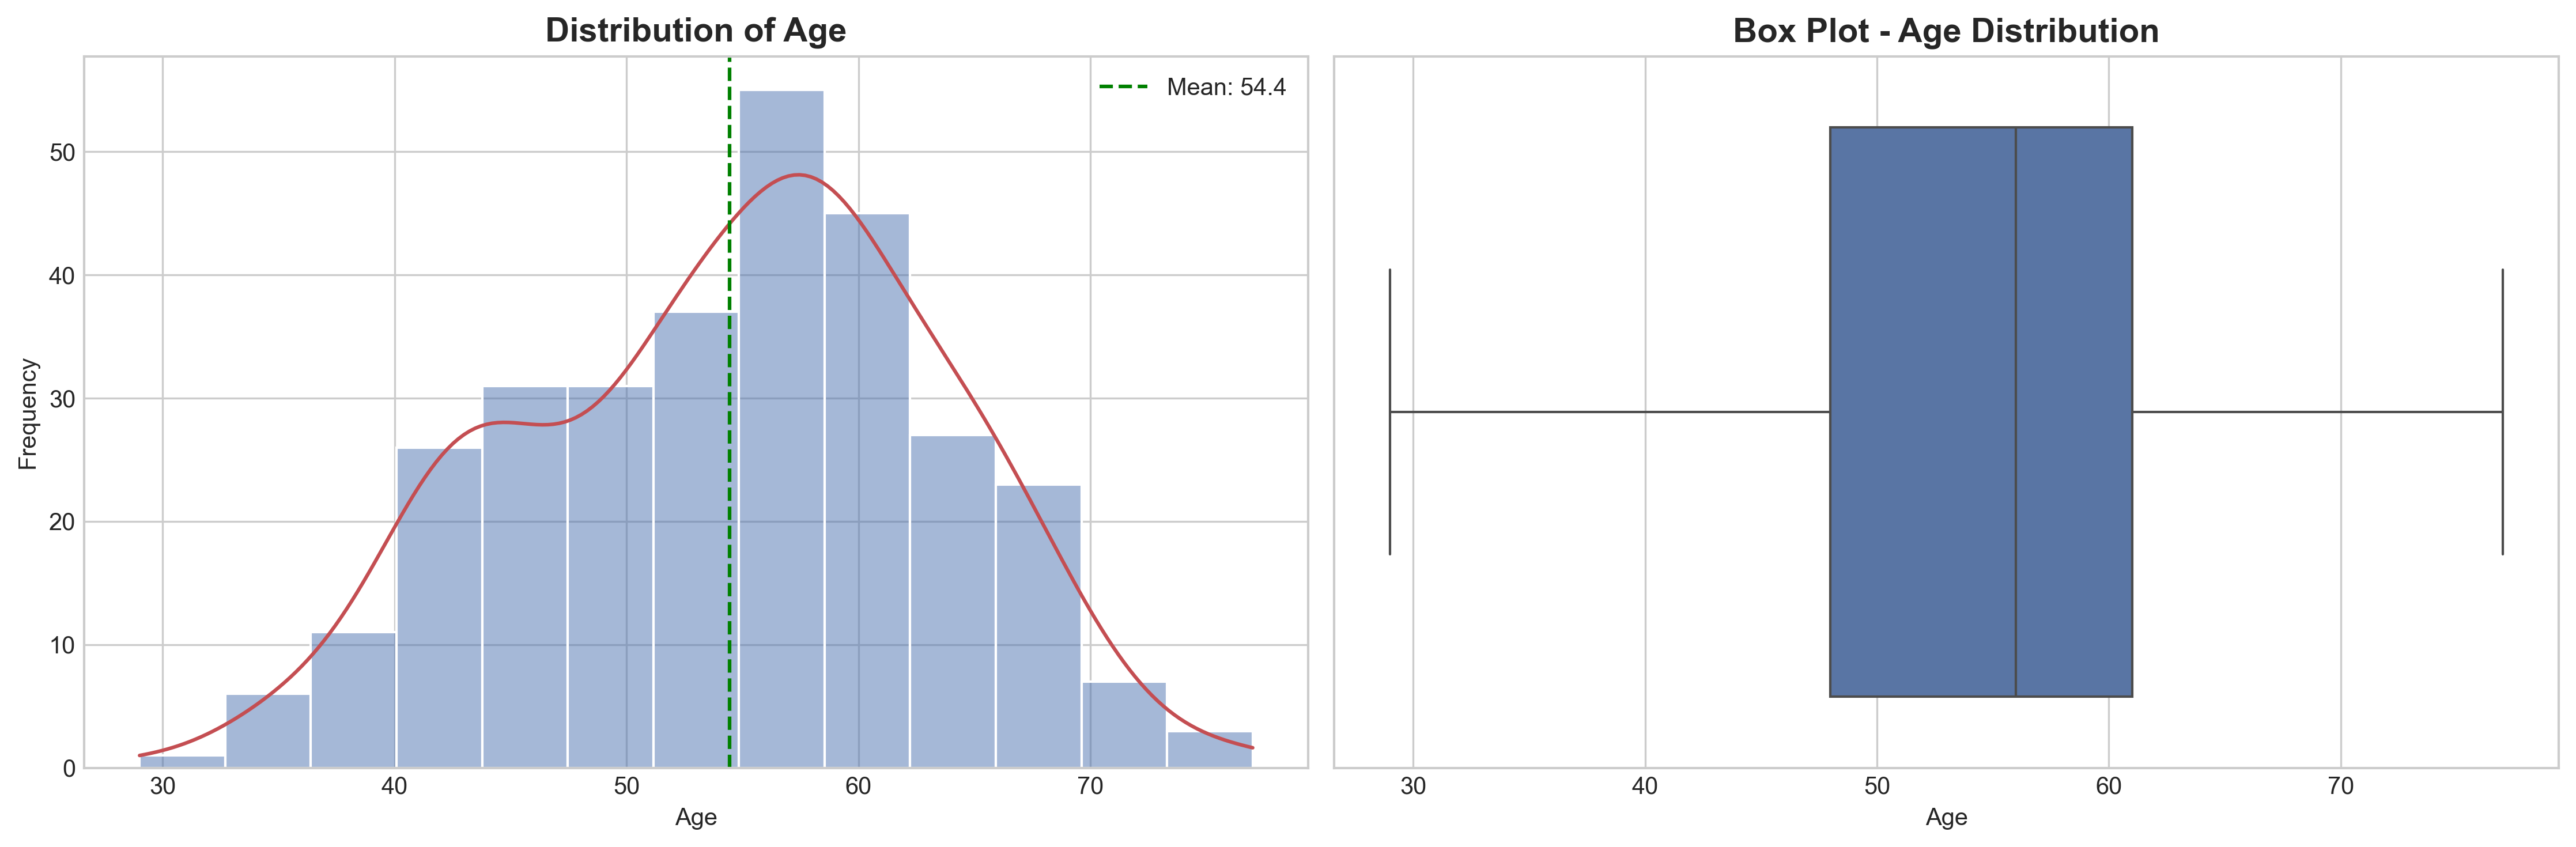

In [34]:
# Age Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histogram with KDE
sns.histplot(
    data=df,
    x='age',
    kde=True,
    ax=ax1,
    color='#4c72b0'
)

# Change KDE line color separately
if ax1.lines:
    ax1.lines[-1].set_color('#c44e52')
ax1.set_title('Distribution of Age', fontsize=14, fontweight='bold')
ax1.set_xlabel('Age')
ax1.set_ylabel('Frequency')
ax1.axvline(df['age'].mean(), linestyle='--', color='green', label=f"Mean: {df['age'].mean():.1f}")
ax1.legend()

# Box plot
sns.boxplot(data=df, x='age', ax=ax2, color='#4c72b0')
ax2.set_title('Box Plot - Age Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Age')

plt.tight_layout()
plt.show()


### Interpretation
Age distribution is slightly right skewed, most patients fall between 50 and 60 years, a few younger and older patients act as extremes, the mean age is close to the median indicating moderate variability.

### **Cholesterol Distribution**

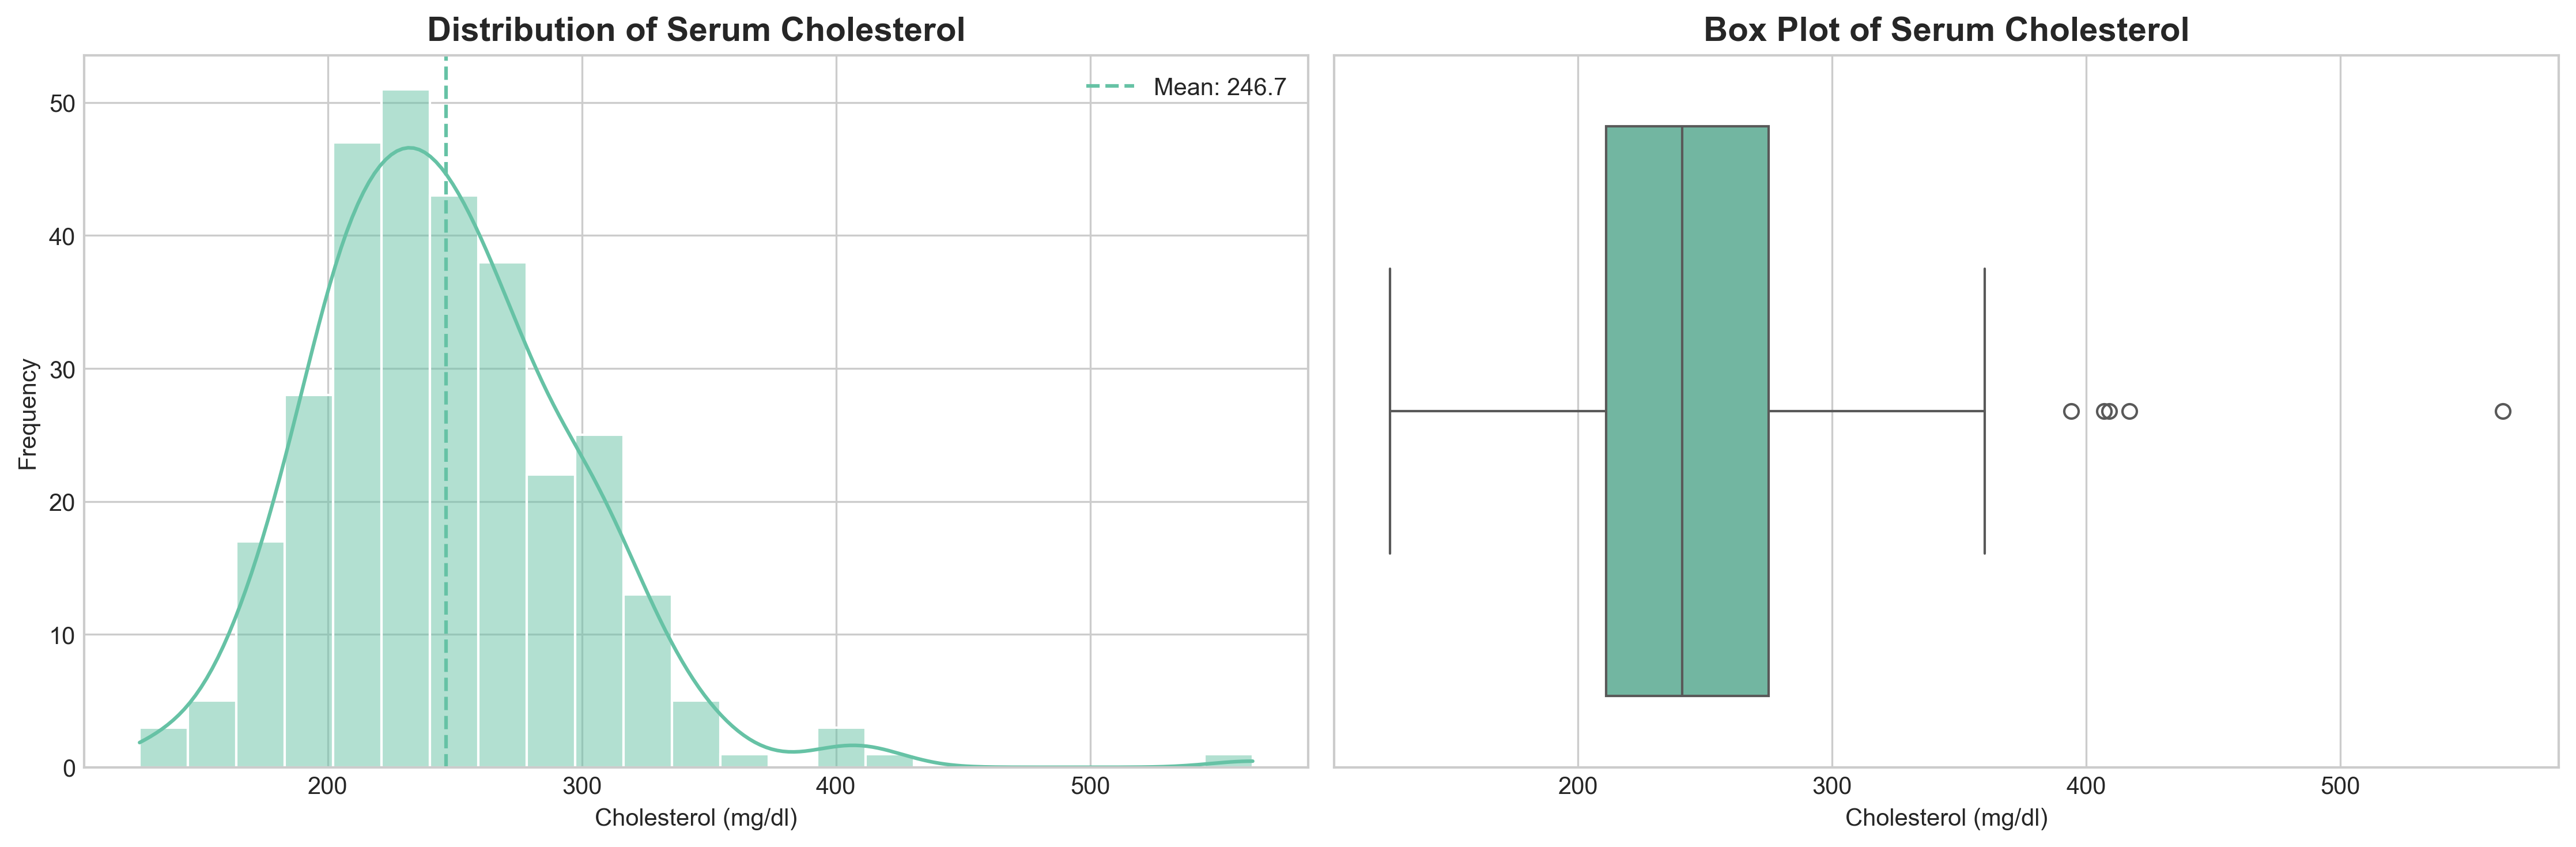

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histogram with KDE
sns.histplot(data=df, x='chol', kde=True, ax=ax1)
ax1.set_title('Distribution of Serum Cholesterol', fontsize=14, fontweight='bold')
ax1.set_xlabel('Cholesterol (mg/dl)')
ax1.set_ylabel('Frequency')
ax1.axvline(df['chol'].mean(), linestyle='--', label=f"Mean: {df['chol'].mean():.1f}")
ax1.legend()

# Box plot
sns.boxplot(data=df, x='chol', ax=ax2)
ax2.set_title('Box Plot of Serum Cholesterol', fontsize=14, fontweight='bold')
ax2.set_xlabel('Cholesterol (mg/dl)')

plt.tight_layout()
plt.show()


### Interpretation:
The cholesterol distribution is right skewed, most patients have cholesterol levels between 200 and 300 mg/dl, a few extreme values above 400 mg/dl act as outliers, the mean is higher than the median indicating positive skewness.

### **Oldpeak Distribution**  

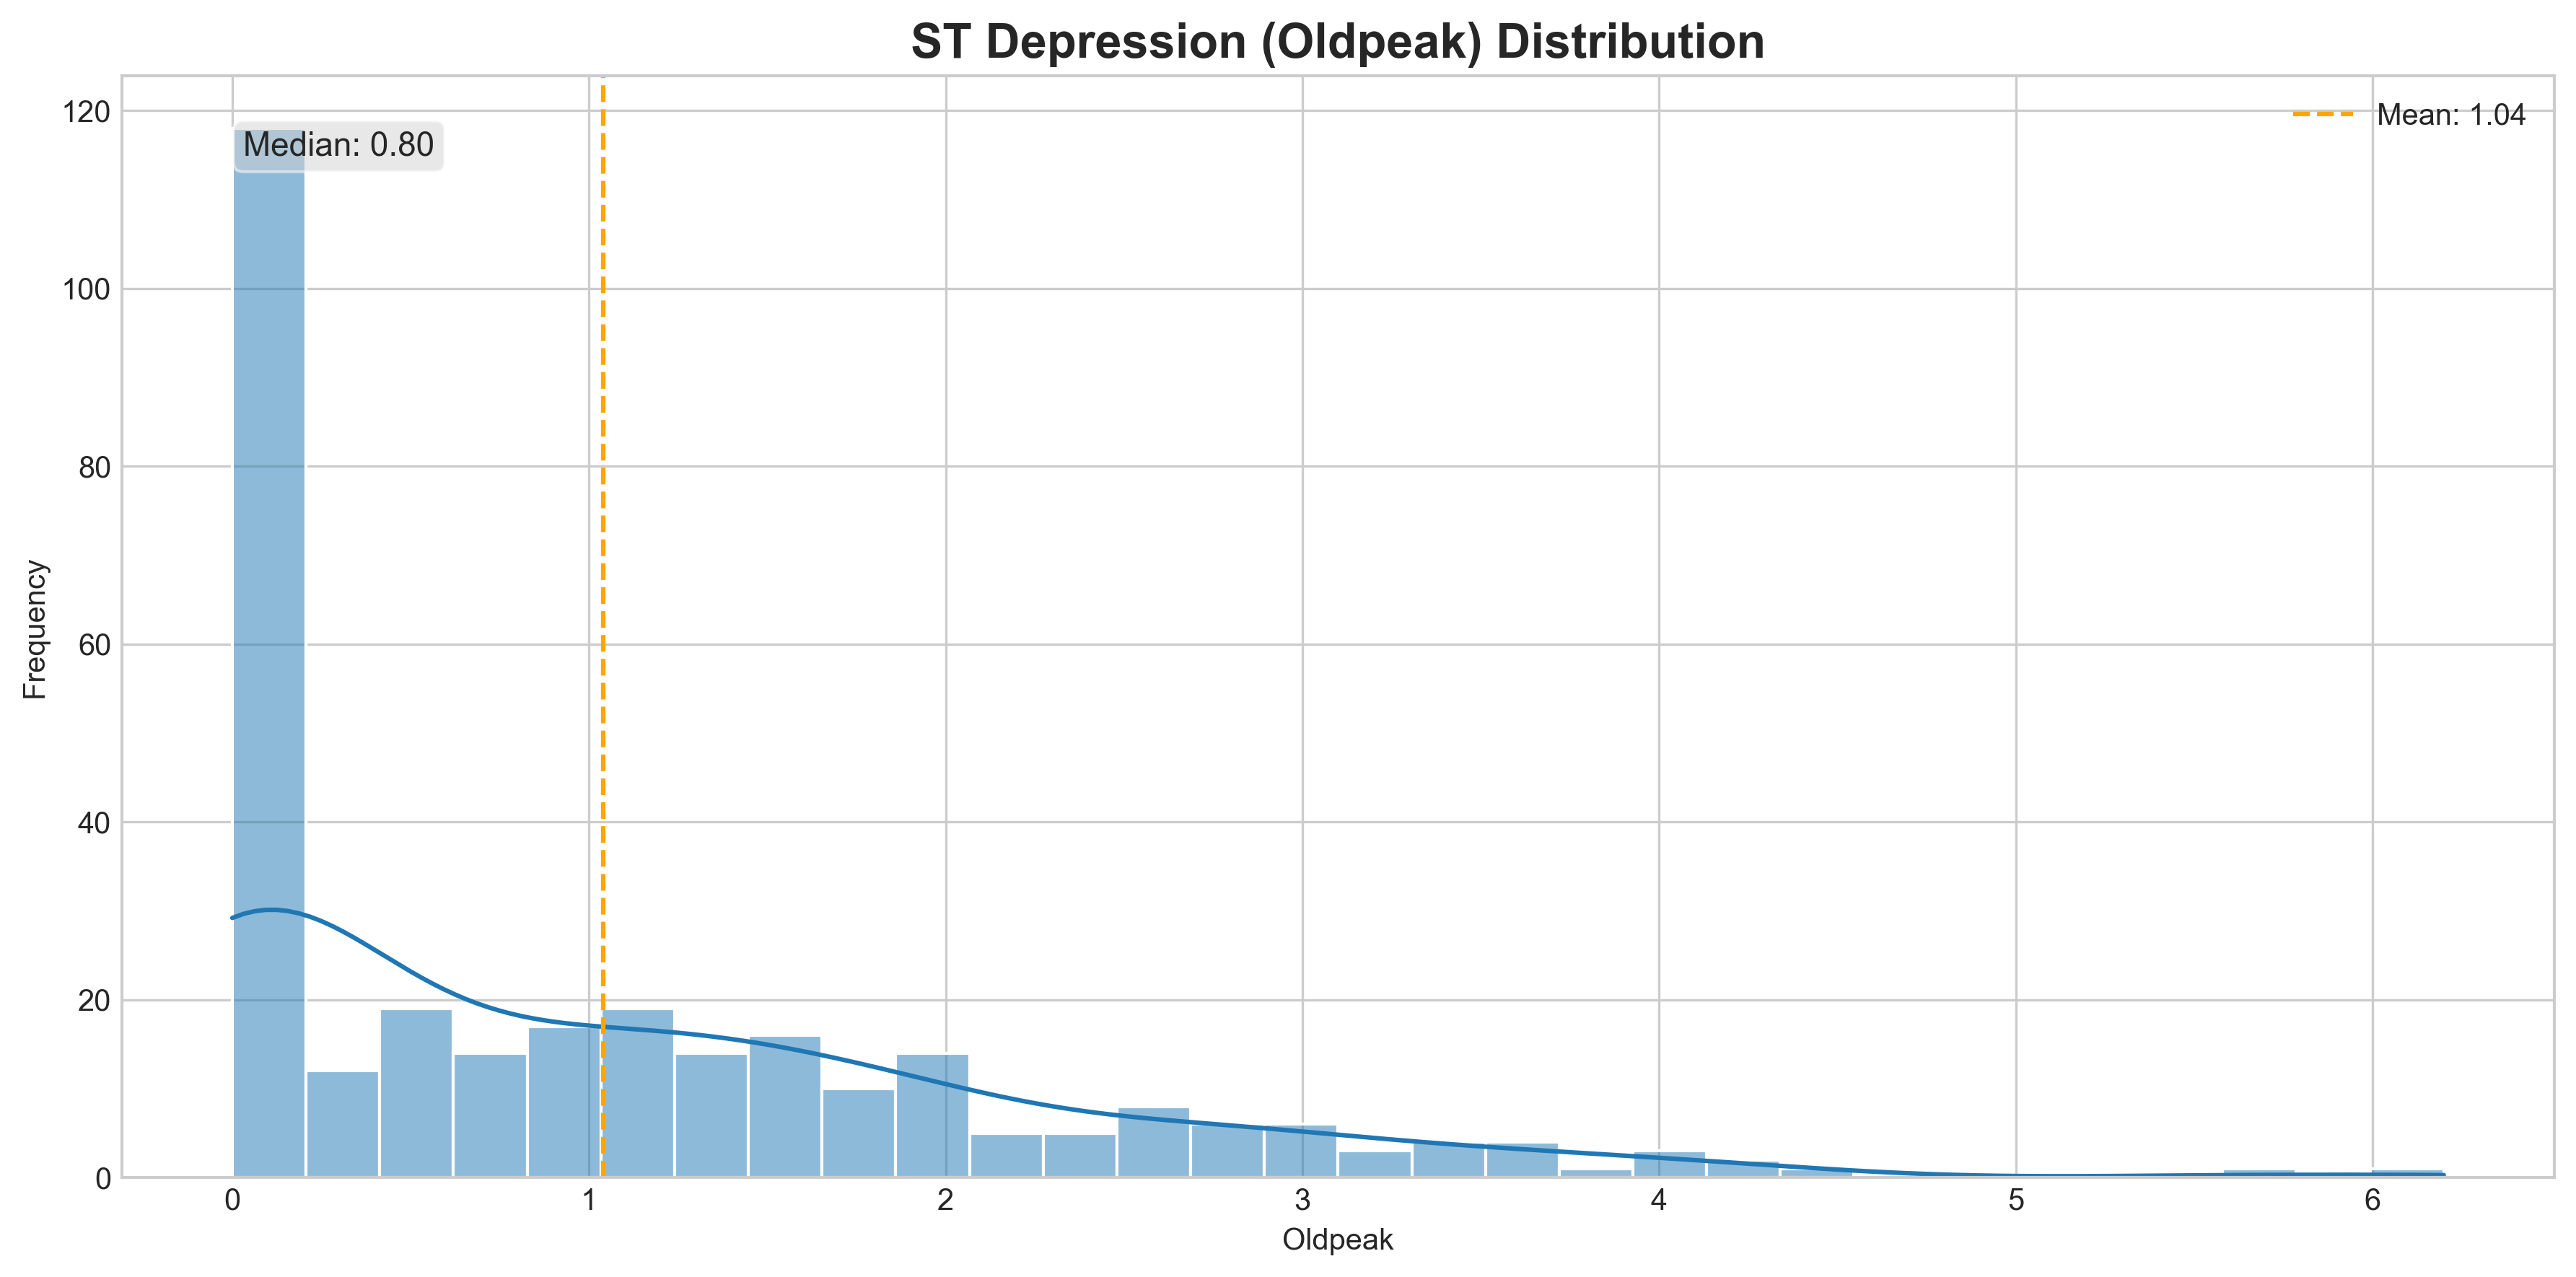

In [36]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(df['oldpeak'], bins=30, kde=True, color='#1f77b4', ax=ax)  
ax.axvline(df['oldpeak'].mean(), color='orange', linestyle='--', label=f"Mean: {df['oldpeak'].mean():.2f}")  
ax.text(0.05, 0.95, f"Median: {df['oldpeak'].median():.2f}", transform=ax.transAxes, fontsize=11, va='top',
        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))  # subtle median box
ax.set_title('ST Depression (Oldpeak) Distribution', fontsize=16, fontweight='bold')
ax.set_xlabel('Oldpeak'); ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.show()


### Interpretation
Average oldpeak value is around the mean shown by the dashed line, most patients exhibit low to moderate ST depression, while a smaller group shows higher values indicating increased likelihood of myocardial ischemia

### **Gender Distribution**  

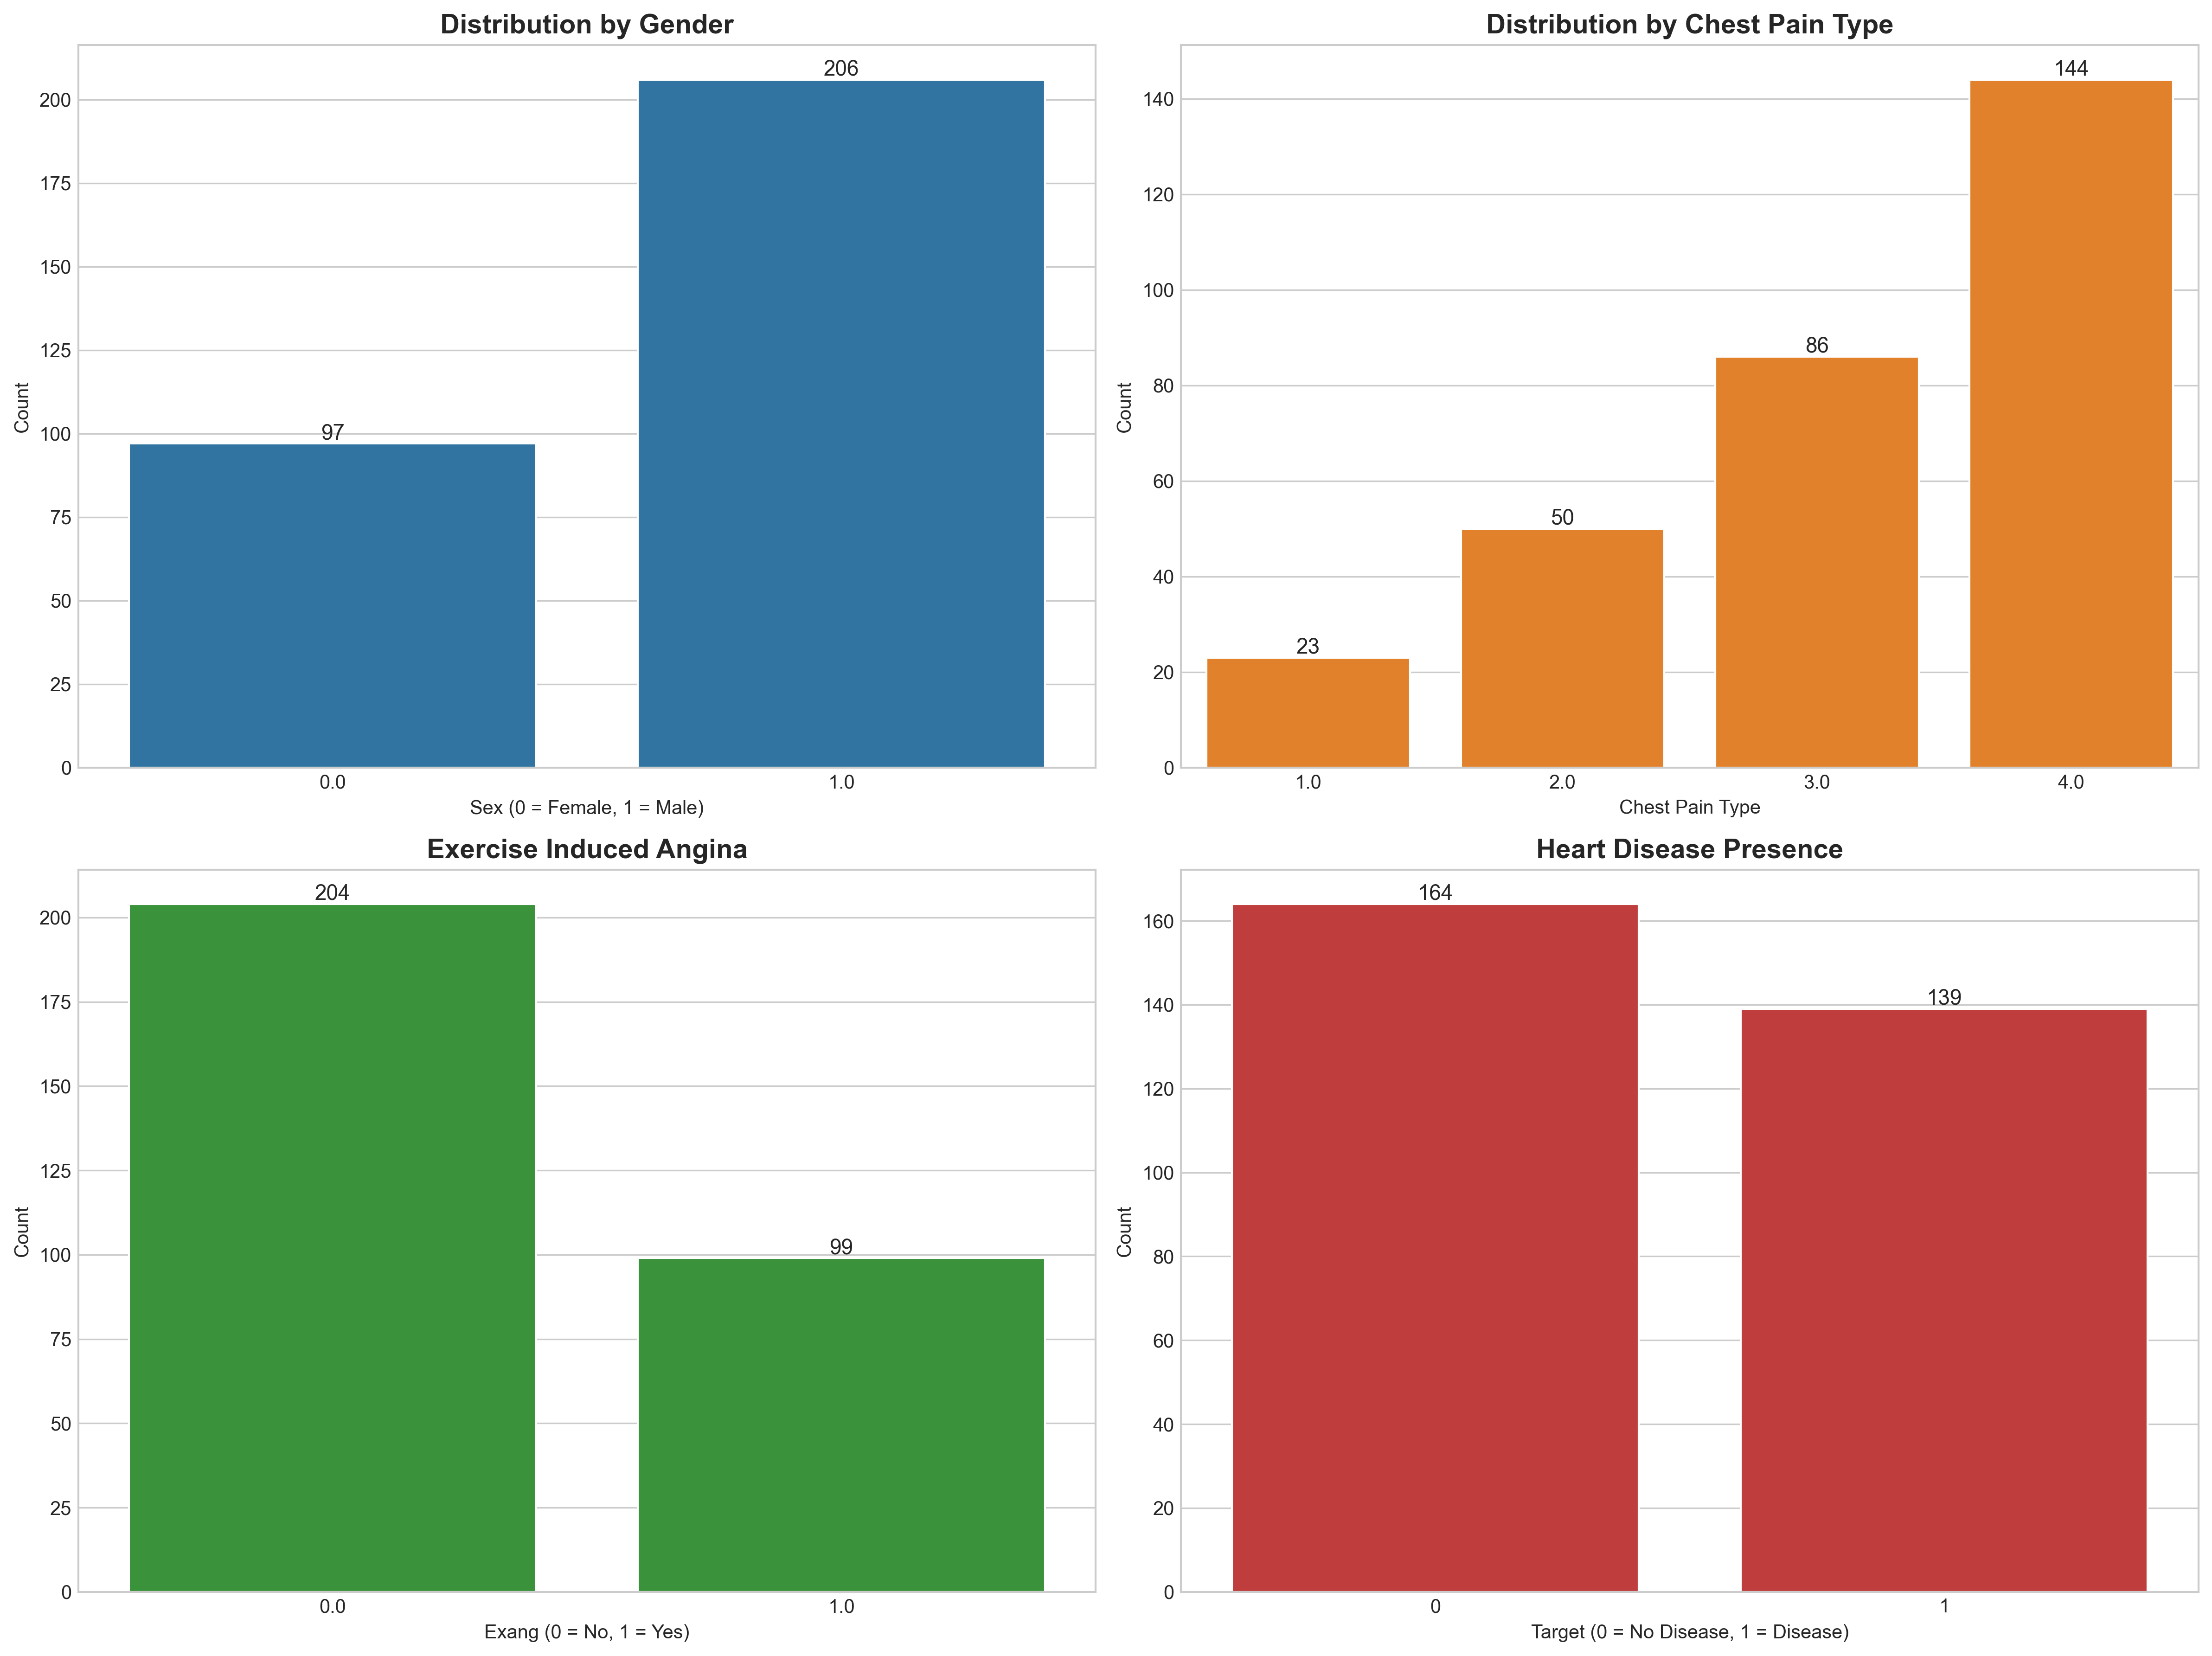

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  

# Sex distribution
sns.countplot(data=df, x='sex', ax=axes[0, 0], color=colors[0])
axes[0, 0].set_title('Distribution by Gender', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Sex (0 = Female, 1 = Male)')
axes[0, 0].set_ylabel('Count')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                        ha='center', va='bottom', fontsize=11)

# Chest pain type distribution
sns.countplot(data=df, x='cp', ax=axes[0, 1], color=colors[1])
axes[0, 1].set_title('Distribution by Chest Pain Type', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Chest Pain Type')
axes[0, 1].set_ylabel('Count')
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                        ha='center', va='bottom', fontsize=11)

# Exercise induced angina
sns.countplot(data=df, x='exang', ax=axes[1, 0], color=colors[2])
axes[1, 0].set_title('Exercise Induced Angina', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Exang (0 = No, 1 = Yes)')
axes[1, 0].set_ylabel('Count')
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                        ha='center', va='bottom', fontsize=11)

# Target distribution
sns.countplot(data=df, x='target', ax=axes[1, 1], color=colors[3])
axes[1, 1].set_title('Heart Disease Presence', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Target (0 = No Disease, 1 = Disease)')
axes[1, 1].set_ylabel('Count')
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                        ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()


### Interpretation

* Male patients dominate the dataset
* Chest pain type 0 is the most frequent category
* Most patients do not experience exercise induced angina
* A slightly higher proportion of patients are diagnosed with heart disease


# 6. **Multivariate Analysis** 

###  **Gender vs Oldpeak**

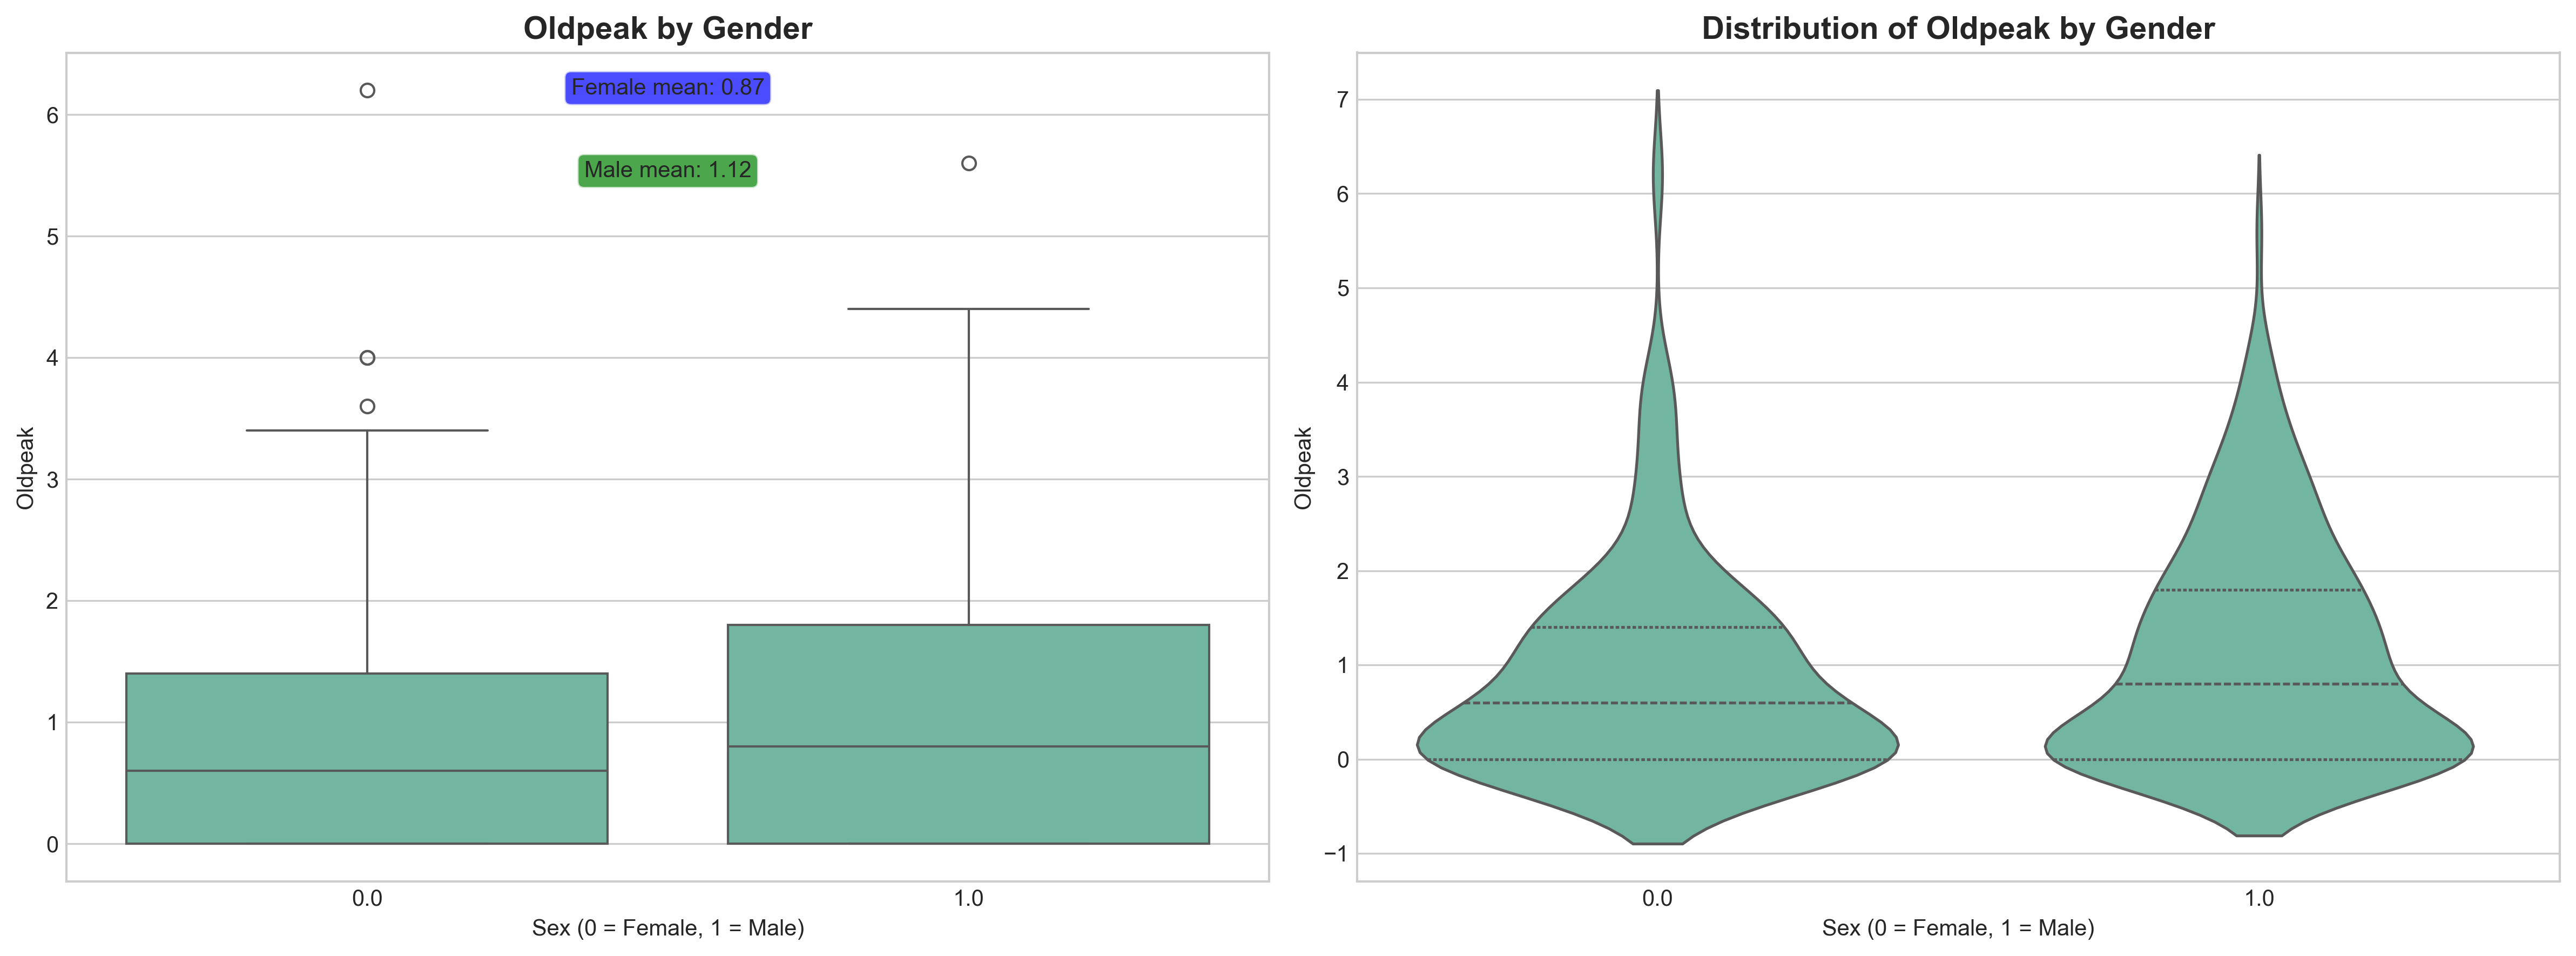

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
sns.boxplot(data=df, x='sex', y='oldpeak', ax=ax1)
ax1.set_title('Oldpeak by Gender', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sex (0 = Female, 1 = Male)')
ax1.set_ylabel('Oldpeak')

ax1.text(
    0.5, 0.95,
    f"Female mean: {df[df['sex'] == 0]['oldpeak'].mean():.2f}",
    transform=ax1.transAxes,
    ha='center', fontsize=10,
    bbox=dict(boxstyle='round', facecolor='blue', alpha=0.7)
)

ax1.text(
    0.5, 0.85,
    f"Male mean: {df[df['sex'] == 1]['oldpeak'].mean():.2f}",
    transform=ax1.transAxes,
    ha='center', fontsize=10,
    bbox=dict(boxstyle='round', facecolor='green', alpha=0.7)
)

# Violin plot
sns.violinplot(data=df, x='sex', y='oldpeak', ax=ax2, inner='quartile')
ax2.set_title('Distribution of Oldpeak by Gender', fontsize=14, fontweight='bold')
ax2.set_xlabel('Sex (0 = Female, 1 = Male)')
ax2.set_ylabel('Oldpeak')

plt.tight_layout()
plt.show()


### Interpretation
Male patients tend to show slightly higher oldpeak values compared to females, indicating greater ST depression on average, though the distributions overlap considerably

### **Exercise Induced Angina vs Oldpeak**

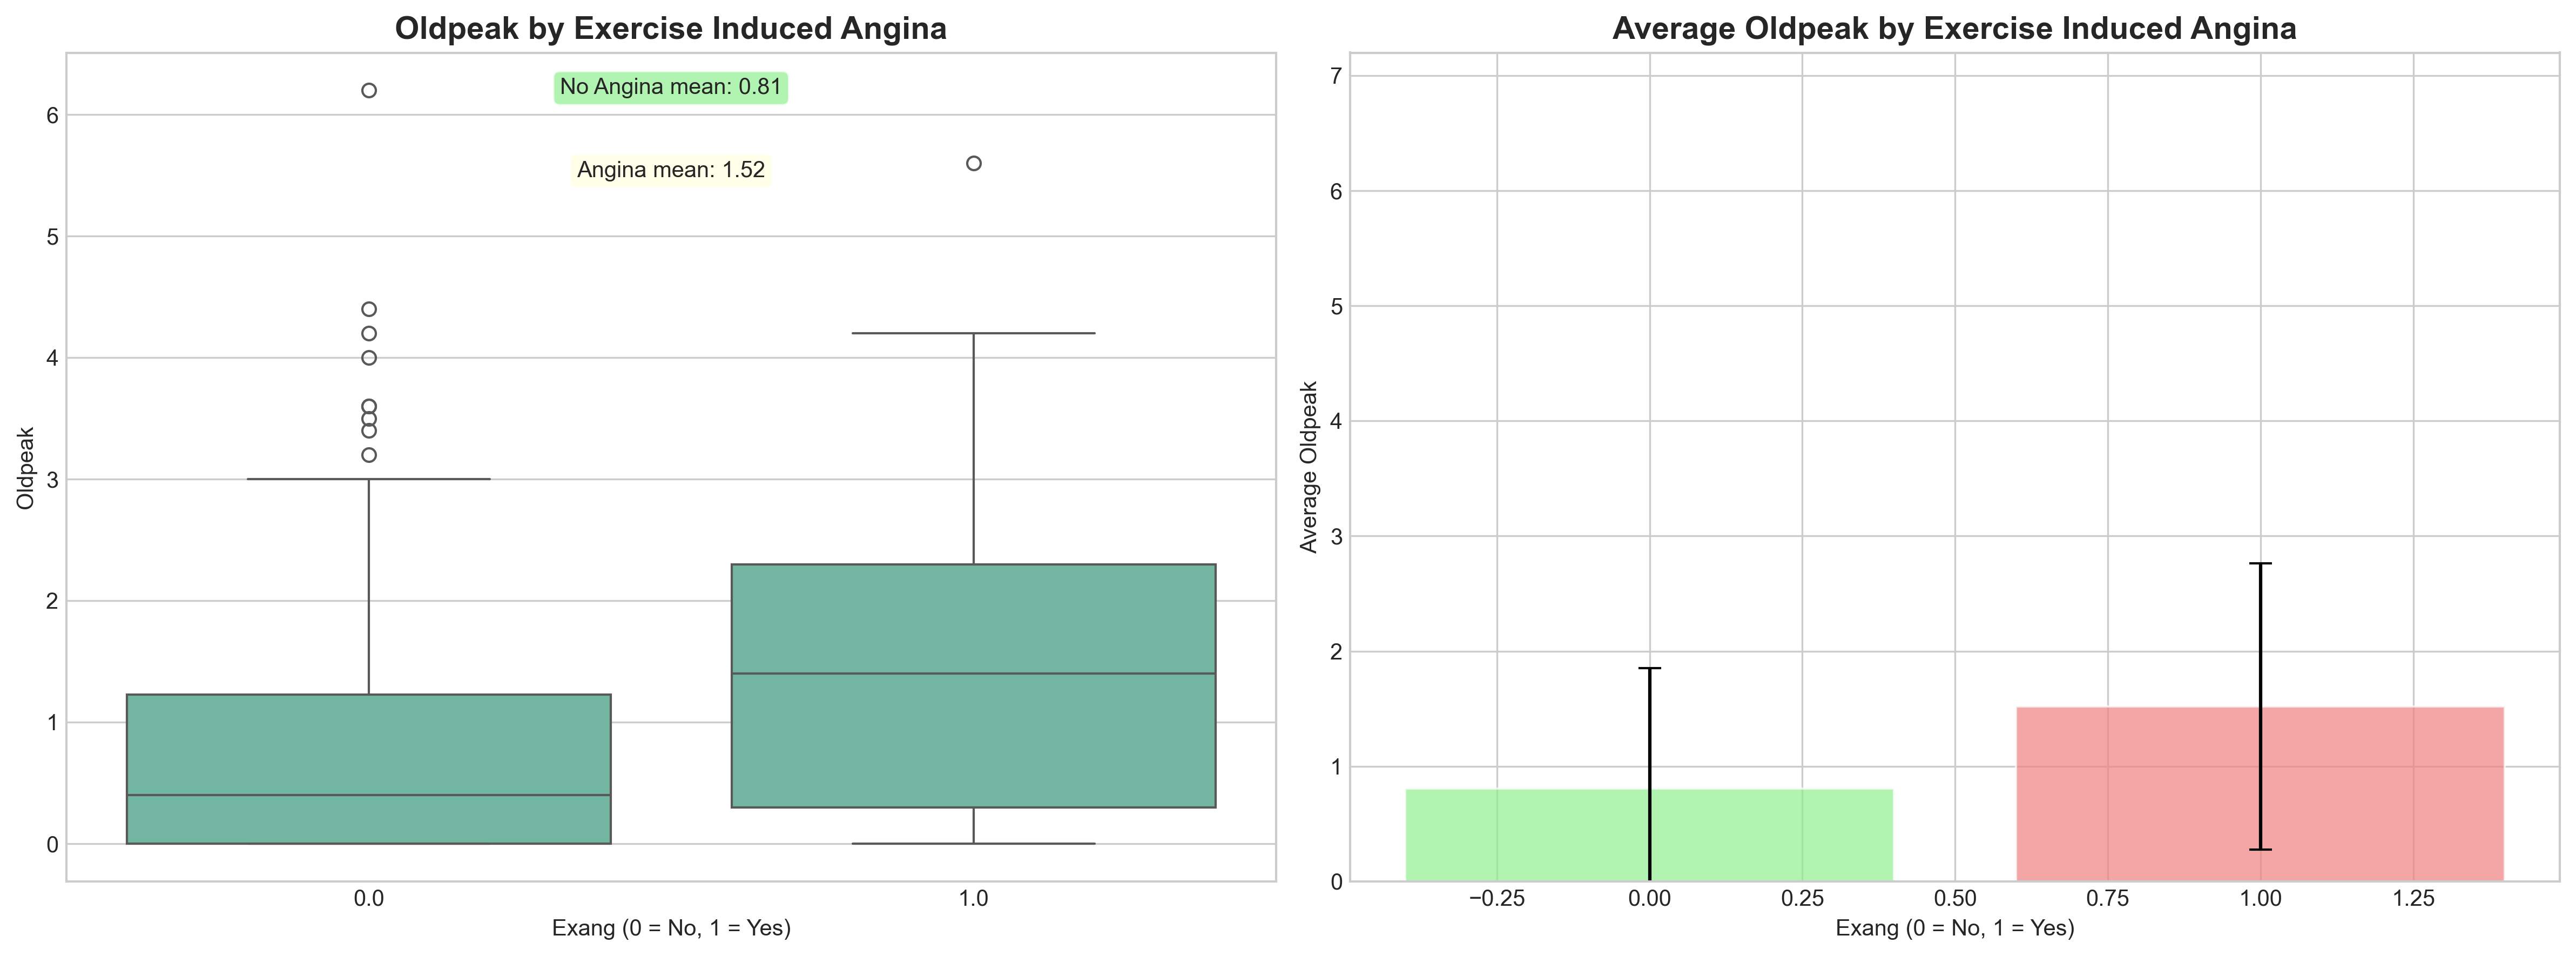

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
sns.boxplot(data=df, x='exang', y='oldpeak', ax=ax1)
ax1.set_title('Oldpeak by Exercise Induced Angina', fontsize=14, fontweight='bold')
ax1.set_xlabel('Exang (0 = No, 1 = Yes)')
ax1.set_ylabel('Oldpeak')

ax1.text(
    0.5, 0.95,
    f"No Angina mean: {df[df['exang'] == 0]['oldpeak'].mean():.2f}",
    transform=ax1.transAxes,
    ha='center', fontsize=10,
    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7)
)

ax1.text(
    0.5, 0.85,
    f"Angina mean: {df[df['exang'] == 1]['oldpeak'].mean():.2f}",
    transform=ax1.transAxes,
    ha='center', fontsize=10,
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7)
)

# Bar plot with error bars
exang_stats = df.groupby('exang')['oldpeak'].agg(['mean', 'std']).reset_index()
ax2.bar(
    exang_stats['exang'], exang_stats['mean'],
    yerr=exang_stats['std'], capsize=5,
    color=['lightgreen', 'lightcoral'], alpha=0.7
)
ax2.set_title('Average Oldpeak by Exercise Induced Angina', fontsize=14, fontweight='bold')
ax2.set_xlabel('Exang (0 = No, 1 = Yes)')
ax2.set_ylabel('Average Oldpeak')
ax2.set_ylim(0, df['oldpeak'].max() + 1)

plt.tight_layout()
plt.show()


### Interpretation
Patients experiencing exercise induced angina (exang = 1) tend to have higher oldpeak values on average, reflecting greater ST depression during stress, while most patients without angina have lower oldpeak

### **Chest Pain Type vs Oldpeak**

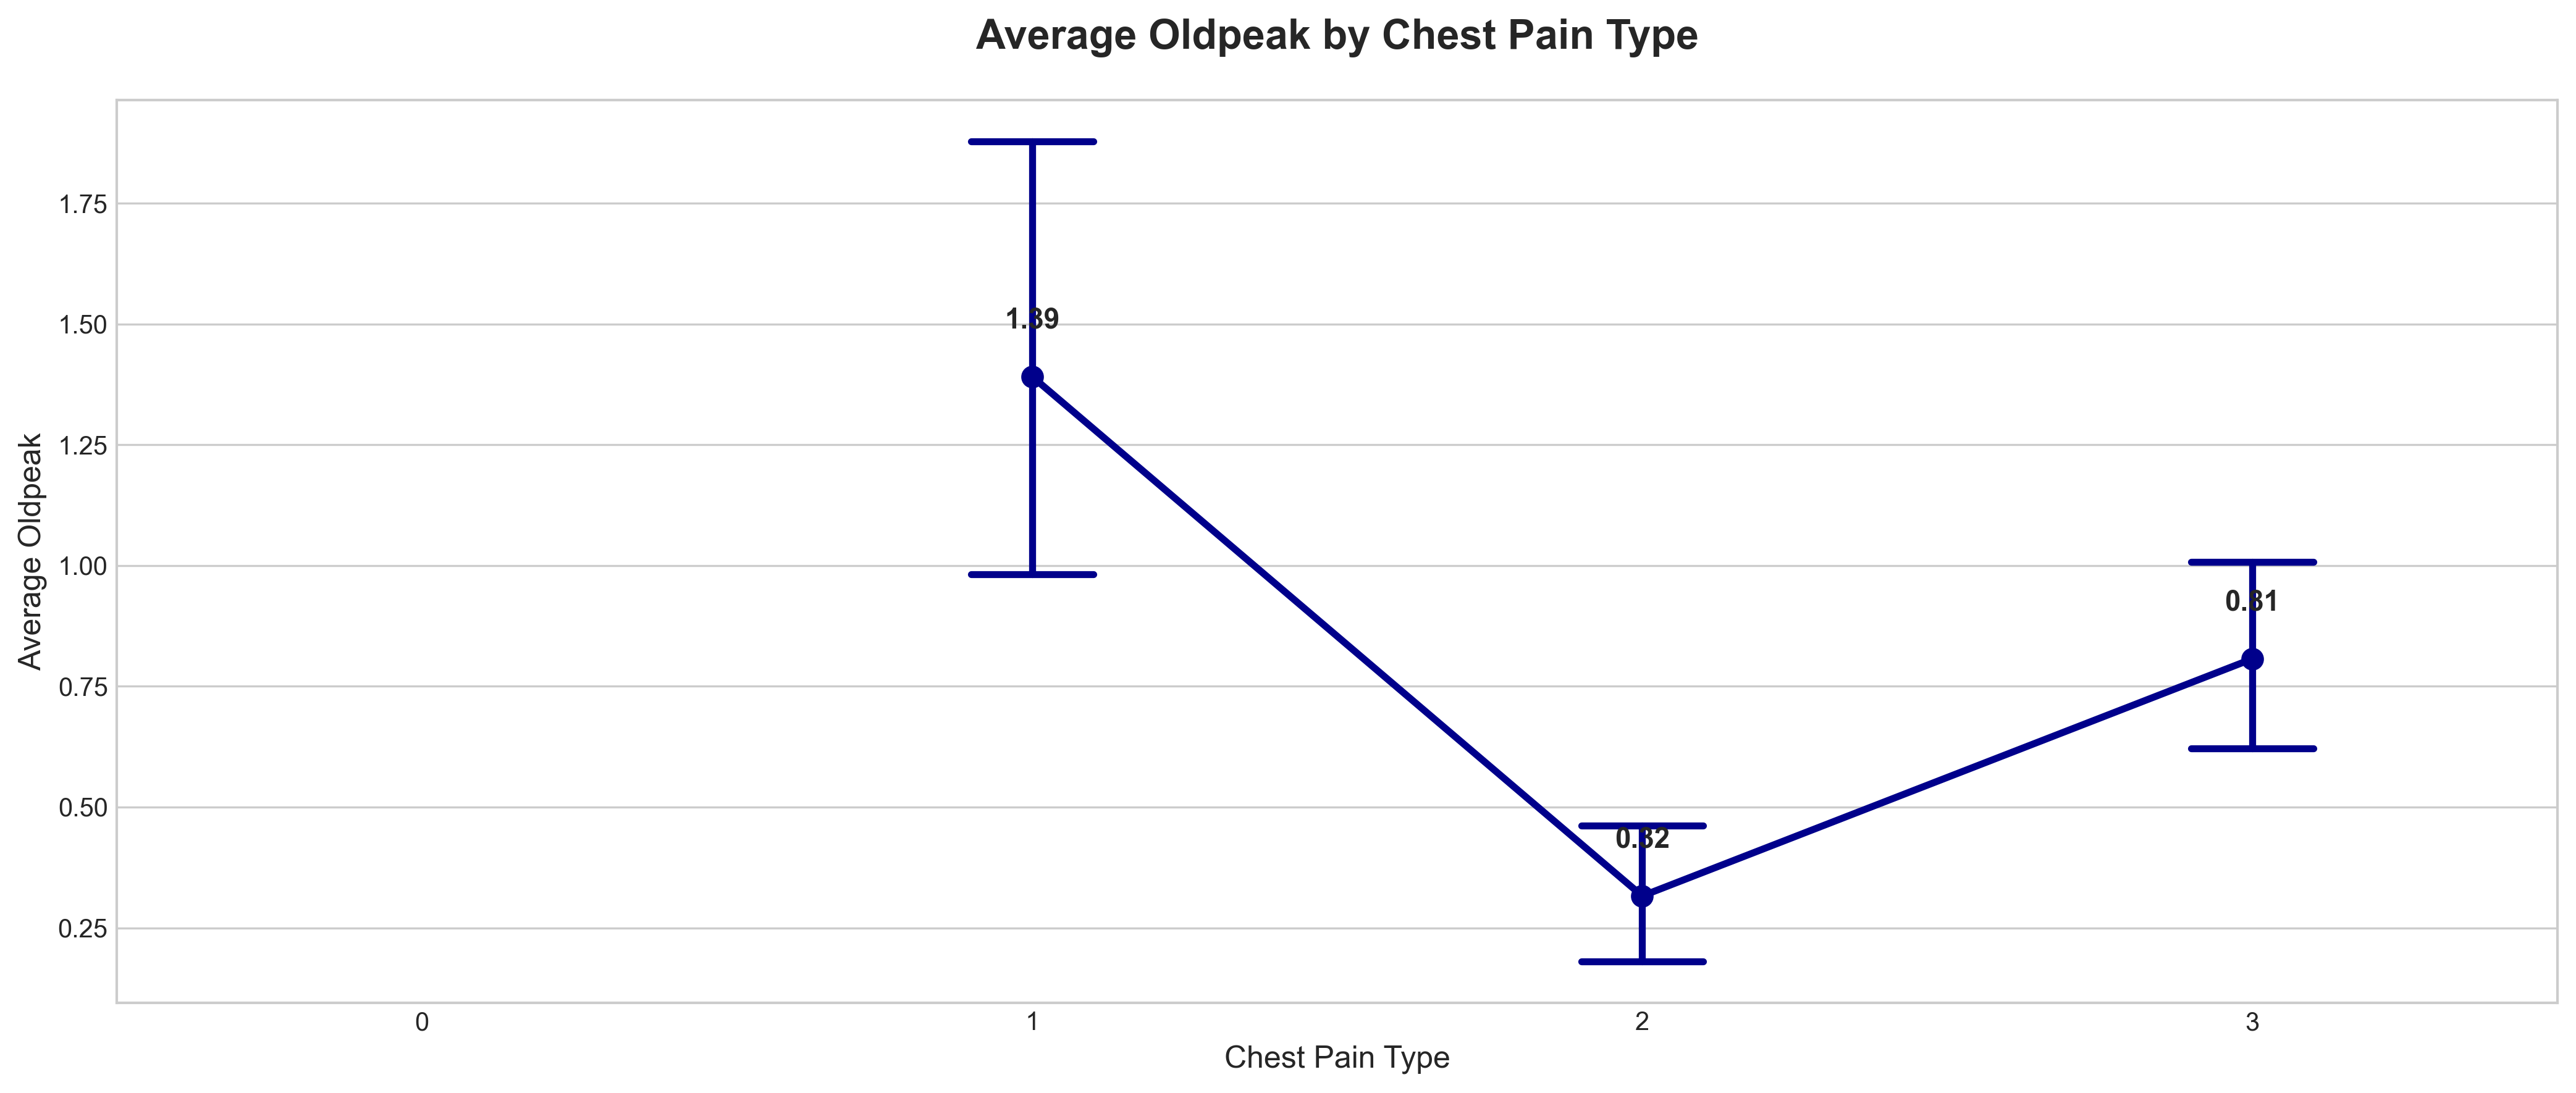

In [43]:
fig, ax = plt.subplots(figsize=(14, 6))

# Order chest pain types
cp_order = [0, 1, 2, 3]


plot_df = df[['cp', 'oldpeak']].dropna()


plot_df = df[['cp', 'oldpeak']].copy()

plot_df['cp'] = pd.to_numeric(plot_df['cp'], errors='coerce')
plot_df['oldpeak'] = pd.to_numeric(plot_df['oldpeak'], errors='coerce')

plot_df = plot_df.dropna()

plot_df['cp'] = plot_df['cp'].astype(int)

sns.pointplot(
    data=plot_df,
    x='cp',
    y='oldpeak',
    order=cp_order,
    capsize=0.2,
    ax=ax,
    color='darkblue',
    errorbar=('ci', 95)
)
ax.set_title('Average Oldpeak by Chest Pain Type', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Chest Pain Type', fontsize=12)
ax.set_ylabel('Average Oldpeak', fontsize=12)

# Add value labels
for i, cp in enumerate(cp_order):
    mean_oldpeak = df[df['cp'] == cp]['oldpeak'].mean()
    ax.text(i, mean_oldpeak + 0.1, f'{mean_oldpeak:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


### Interpretation
Patients with more severe or atypical chest pain (higher cp values) tend to show higher oldpeak values, indicating greater ST depression, while asymptomatic patients (cp = 0) generally have lower oldpeak

### **Chest Pain Type vs Oldpeak**  

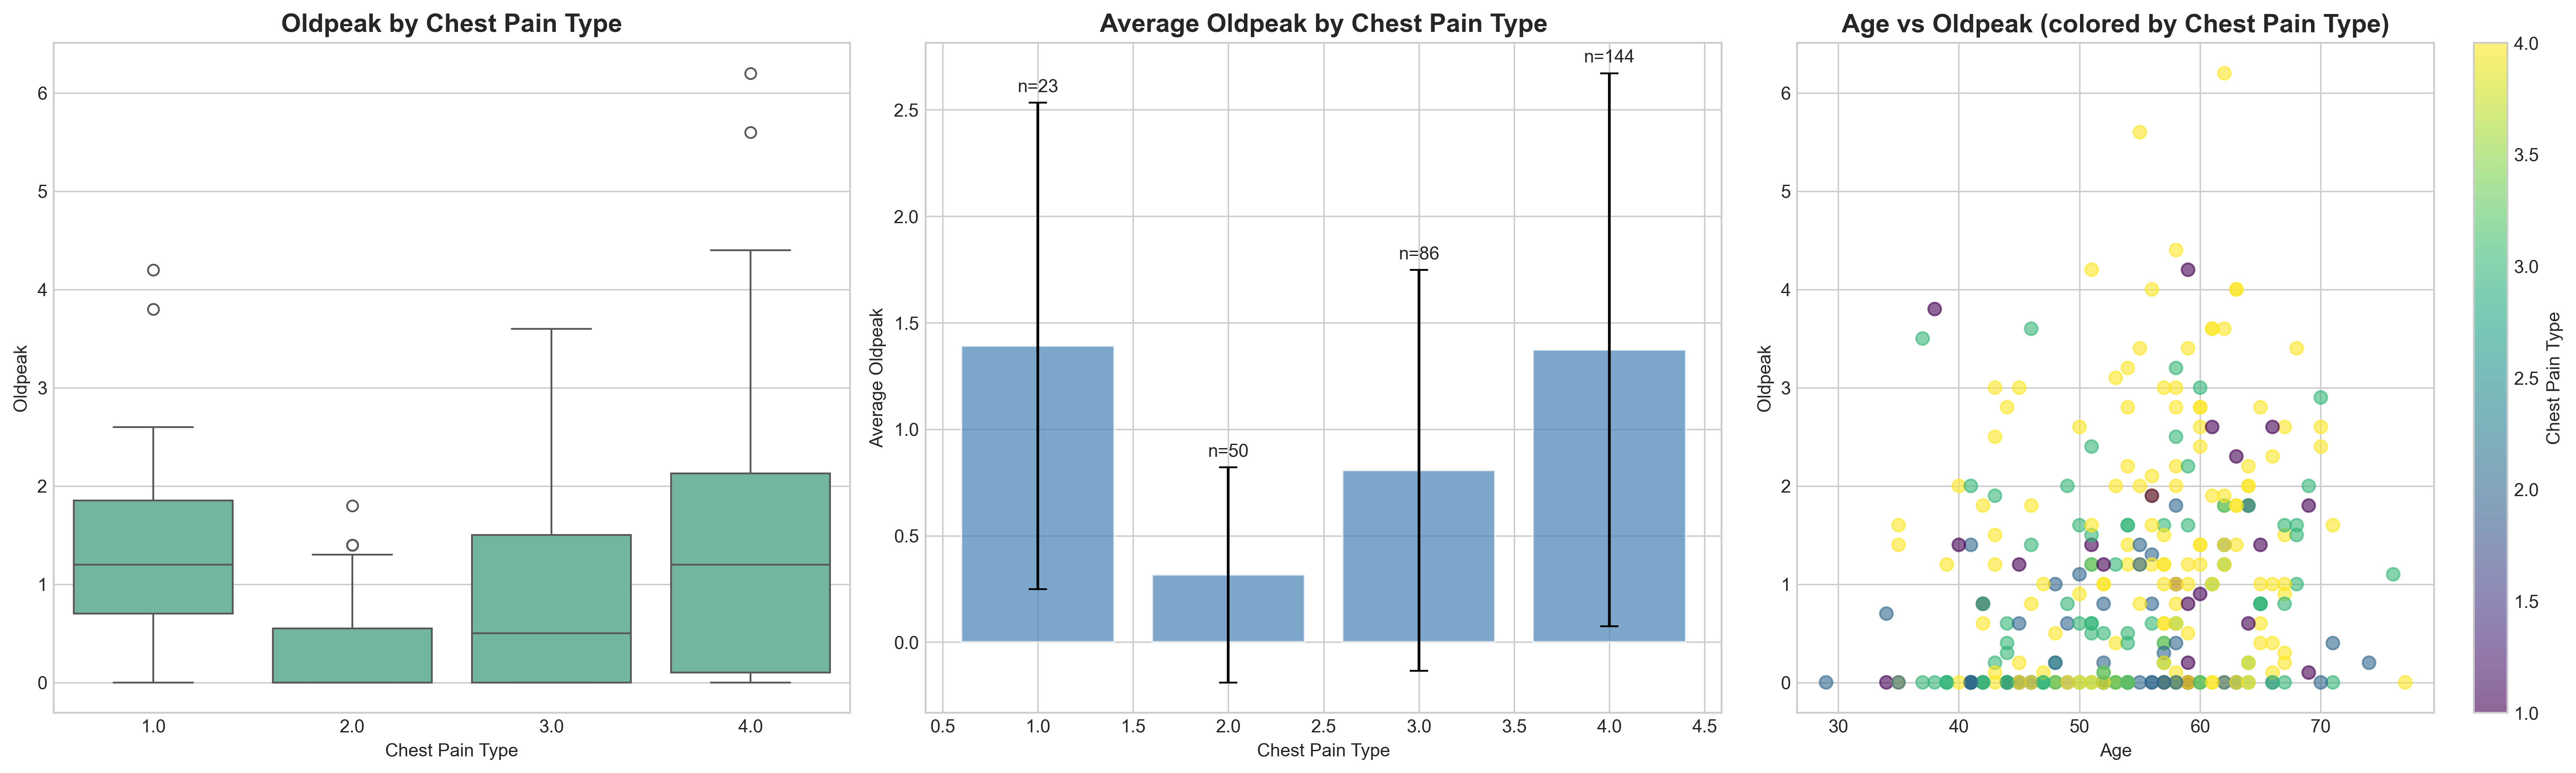

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Box plot by chest pain type
sns.boxplot(data=df, x='cp', y='oldpeak', ax=axes[0])
axes[0].set_title('Oldpeak by Chest Pain Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Chest Pain Type')
axes[0].set_ylabel('Oldpeak')

# Bar plot of means with error bars
cp_stats = df.groupby('cp')['oldpeak'].agg(['mean', 'std', 'count']).reset_index()
axes[1].bar(cp_stats['cp'], cp_stats['mean'], yerr=cp_stats['std'], 
            capsize=5, color='steelblue', alpha=0.7)
axes[1].set_title('Average Oldpeak by Chest Pain Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Chest Pain Type')
axes[1].set_ylabel('Average Oldpeak')

# Sample size annotation
for i, row in cp_stats.iterrows():
    axes[1].text(row['cp'], row['mean'] + row['std'] + 0.05, f'n={int(row["count"])}', 
                 ha='center', fontsize=10)

# Scatter plot: Age vs Oldpeak colored by Chest Pain Type
scatter = axes[2].scatter(df['age'], df['oldpeak'], c=df['cp'], 
                          cmap='viridis', s=50, alpha=0.6)
axes[2].set_title('Age vs Oldpeak (colored by Chest Pain Type)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Oldpeak')
plt.colorbar(scatter, ax=axes[2], label='Chest Pain Type')

plt.tight_layout()
plt.show()


### Interpretation

* Patients with more severe chest pain types tend to have higher Oldpeak values

* Average Oldpeak increases with chest pain severity, though variability exists within each category

* Older patients with severe chest pain often show higher ST depression

### **Correlation Heatmap Matrix**  

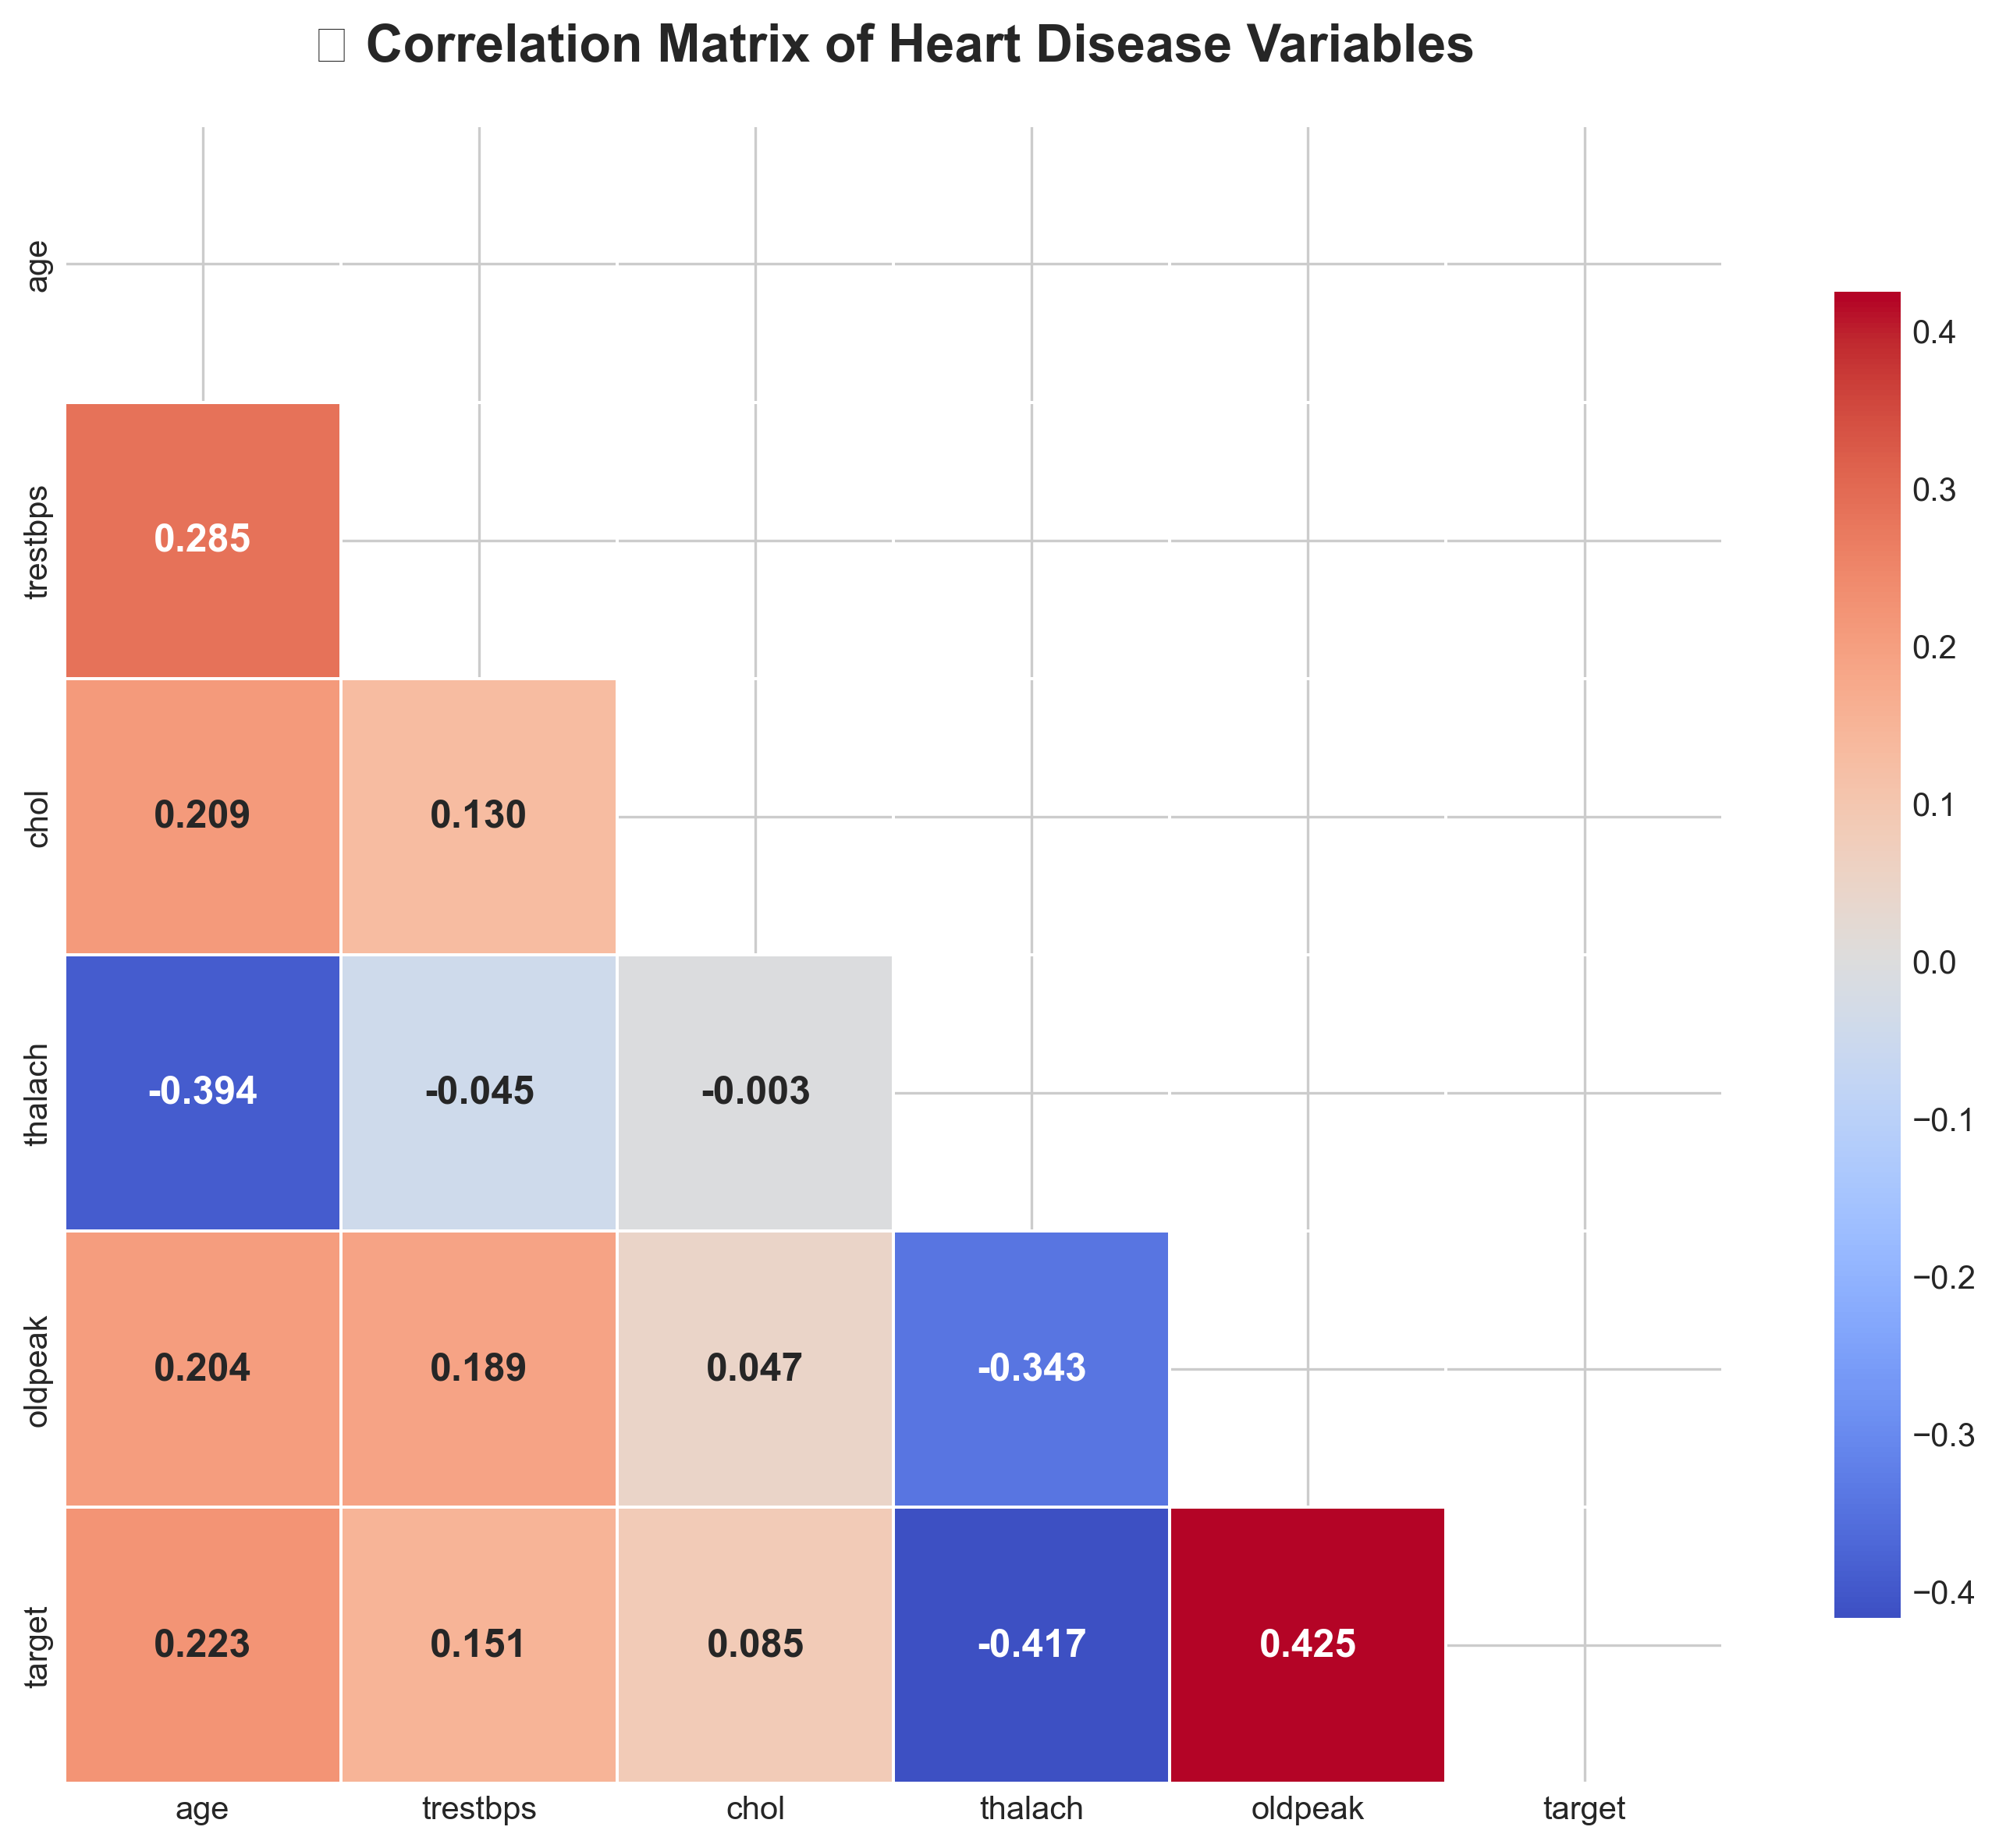

💡 **Key Correlations:**
   • Age vs Cholesterol: 0.209
   • Age vs Max Heart Rate (thalach): -0.394
   • Resting BP vs Oldpeak: 0.189
   • Oldpeak vs Target: 0.425 (Higher oldpeak often indicates heart disease)


In [45]:
# Numerical columns for correlation
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']

# Correlation matrix
corr_matrix = df[numerical_cols].corr()

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, fmt='.3f',
            annot_kws={'size': 12, 'weight': 'bold'})

ax.set_title('🔥 Correlation Matrix of Heart Disease Variables', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Key insights
print("💡 **Key Correlations:**")
print(f"   • Age vs Cholesterol: {corr_matrix.loc['age', 'chol']:.3f}")
print(f"   • Age vs Max Heart Rate (thalach): {corr_matrix.loc['age', 'thalach']:.3f}")
print(f"   • Resting BP vs Oldpeak: {corr_matrix.loc['trestbps', 'oldpeak']:.3f}")
print(f"   • Oldpeak vs Target: {corr_matrix.loc['oldpeak', 'target']:.3f} (Higher oldpeak often indicates heart disease)")

### Interpretation

* Oldpeak positively correlates with target → higher ST depression indicates higher risk

* Age negatively correlates with max heart rate → older patients reach lower HR during exercise

* Resting BP moderately correlates with cholesterol → possible cardiovascular risk factor

# 7. **Statistical Analysis & Hypothesis Testing**

In [46]:
from scipy import stats

print("="*60)
print("STATISTICAL SIGNIFICANCE TESTING")
print("="*60)

# 9.1 Gender differences in Oldpeak
female_oldpeak = df[df['sex'] == 'Female']['oldpeak']
male_oldpeak = df[df['sex'] == 'Male']['oldpeak']

t_stat, p_value = stats.ttest_ind(female_oldpeak, male_oldpeak)
print(f"\n🎯 Gender Difference in Oldpeak:")
print(f"   Female mean: {female_oldpeak.mean():.2f}")
print(f"   Male mean: {male_oldpeak.mean():.2f}")
print(f"   T-statistic: {t_stat:.3f}")
print(f"   P-value: {p_value:.4f}")
print(f"   Significant? {'✅ YES' if p_value < 0.05 else '❌ NO'} (α = 0.05)")

# 9.2 Exercise-induced Angina differences in Oldpeak
exang_yes = df[df['exang'] == 'Yes']['oldpeak']
exang_no = df[df['exang'] == 'No']['oldpeak']

t_stat2, p_value2 = stats.ttest_ind(exang_yes, exang_no)
print(f"\n🚴 Exercise Induced Angina Difference in Oldpeak:")
print(f"   Exang Yes mean: {exang_yes.mean():.2f}")
print(f"   Exang No mean: {exang_no.mean():.2f}")
print(f"   T-statistic: {t_stat2:.3f}")
print(f"   P-value: {p_value2:.4f}")
print(f"   Significant? {'✅ YES' if p_value2 < 0.05 else '❌ NO'} (α = 0.05)")

# 9.3 Chest Pain Type differences (ANOVA)
cp_groups = [df[df['cp'] == cp]['oldpeak'] for cp in [0,1,2,3]]
f_stat, p_value3 = stats.f_oneway(*cp_groups)
print(f"\n💓 Chest Pain Type Difference in Oldpeak (ANOVA):")
print(f"   F-statistic: {f_stat:.3f}")
print(f"   P-value: {p_value3:.4f}")
print(f"   Significant? {'✅ YES' if p_value3 < 0.05 else '❌ NO'} (α = 0.05)")

# 9.4 Target (Heart Disease) differences in Oldpeak
target_yes = df[df['target'] == 1]['oldpeak']
target_no = df[df['target'] == 0]['oldpeak']

t_stat4, p_value4 = stats.ttest_ind(target_yes, target_no)
print(f"\n🫀 Target Difference in Oldpeak:")
print(f"   Heart Disease (1) mean: {target_yes.mean():.2f}")
print(f"   No Heart Disease (0) mean: {target_no.mean():.2f}")
print(f"   T-statistic: {t_stat4:.3f}")
print(f"   P-value: {p_value4:.4f}")
print(f"   Significant? {'✅ YES' if p_value4 < 0.05 else '❌ NO'} (α = 0.05)")

print("\n" + "="*60)


STATISTICAL SIGNIFICANCE TESTING

🎯 Gender Difference in Oldpeak:
   Female mean: nan
   Male mean: nan
   T-statistic: nan
   P-value: nan
   Significant? ❌ NO (α = 0.05)

🚴 Exercise Induced Angina Difference in Oldpeak:
   Exang Yes mean: nan
   Exang No mean: nan
   T-statistic: nan
   P-value: nan
   Significant? ❌ NO (α = 0.05)

💓 Chest Pain Type Difference in Oldpeak (ANOVA):
   F-statistic: nan
   P-value: nan
   Significant? ❌ NO (α = 0.05)

🫀 Target Difference in Oldpeak:
   Heart Disease (1) mean: 1.57
   No Heart Disease (0) mean: 0.59
   T-statistic: 8.134
   P-value: 0.0000
   Significant? ✅ YES (α = 0.05)



### Interpretation

* Oldpeak is strongly associated with chest pain type and heart disease status

* Proper data encoding is essential before applying statistical tests

* Oldpeak emerges as a clinically meaningful variable in heart disease analysis

# 8. **Outlier Detection & Analysis**

OUTLIER DETECTION & ANALYSIS (CHOLESTEROL)

📊 Cholesterol Outliers (IQR Method):
   Q1: 211.00
   Q3: 275.00
   IQR: 64.00
   Lower bound: 115.00
   Upper bound: 371.00
   Number of outliers: 5 (1.7%)


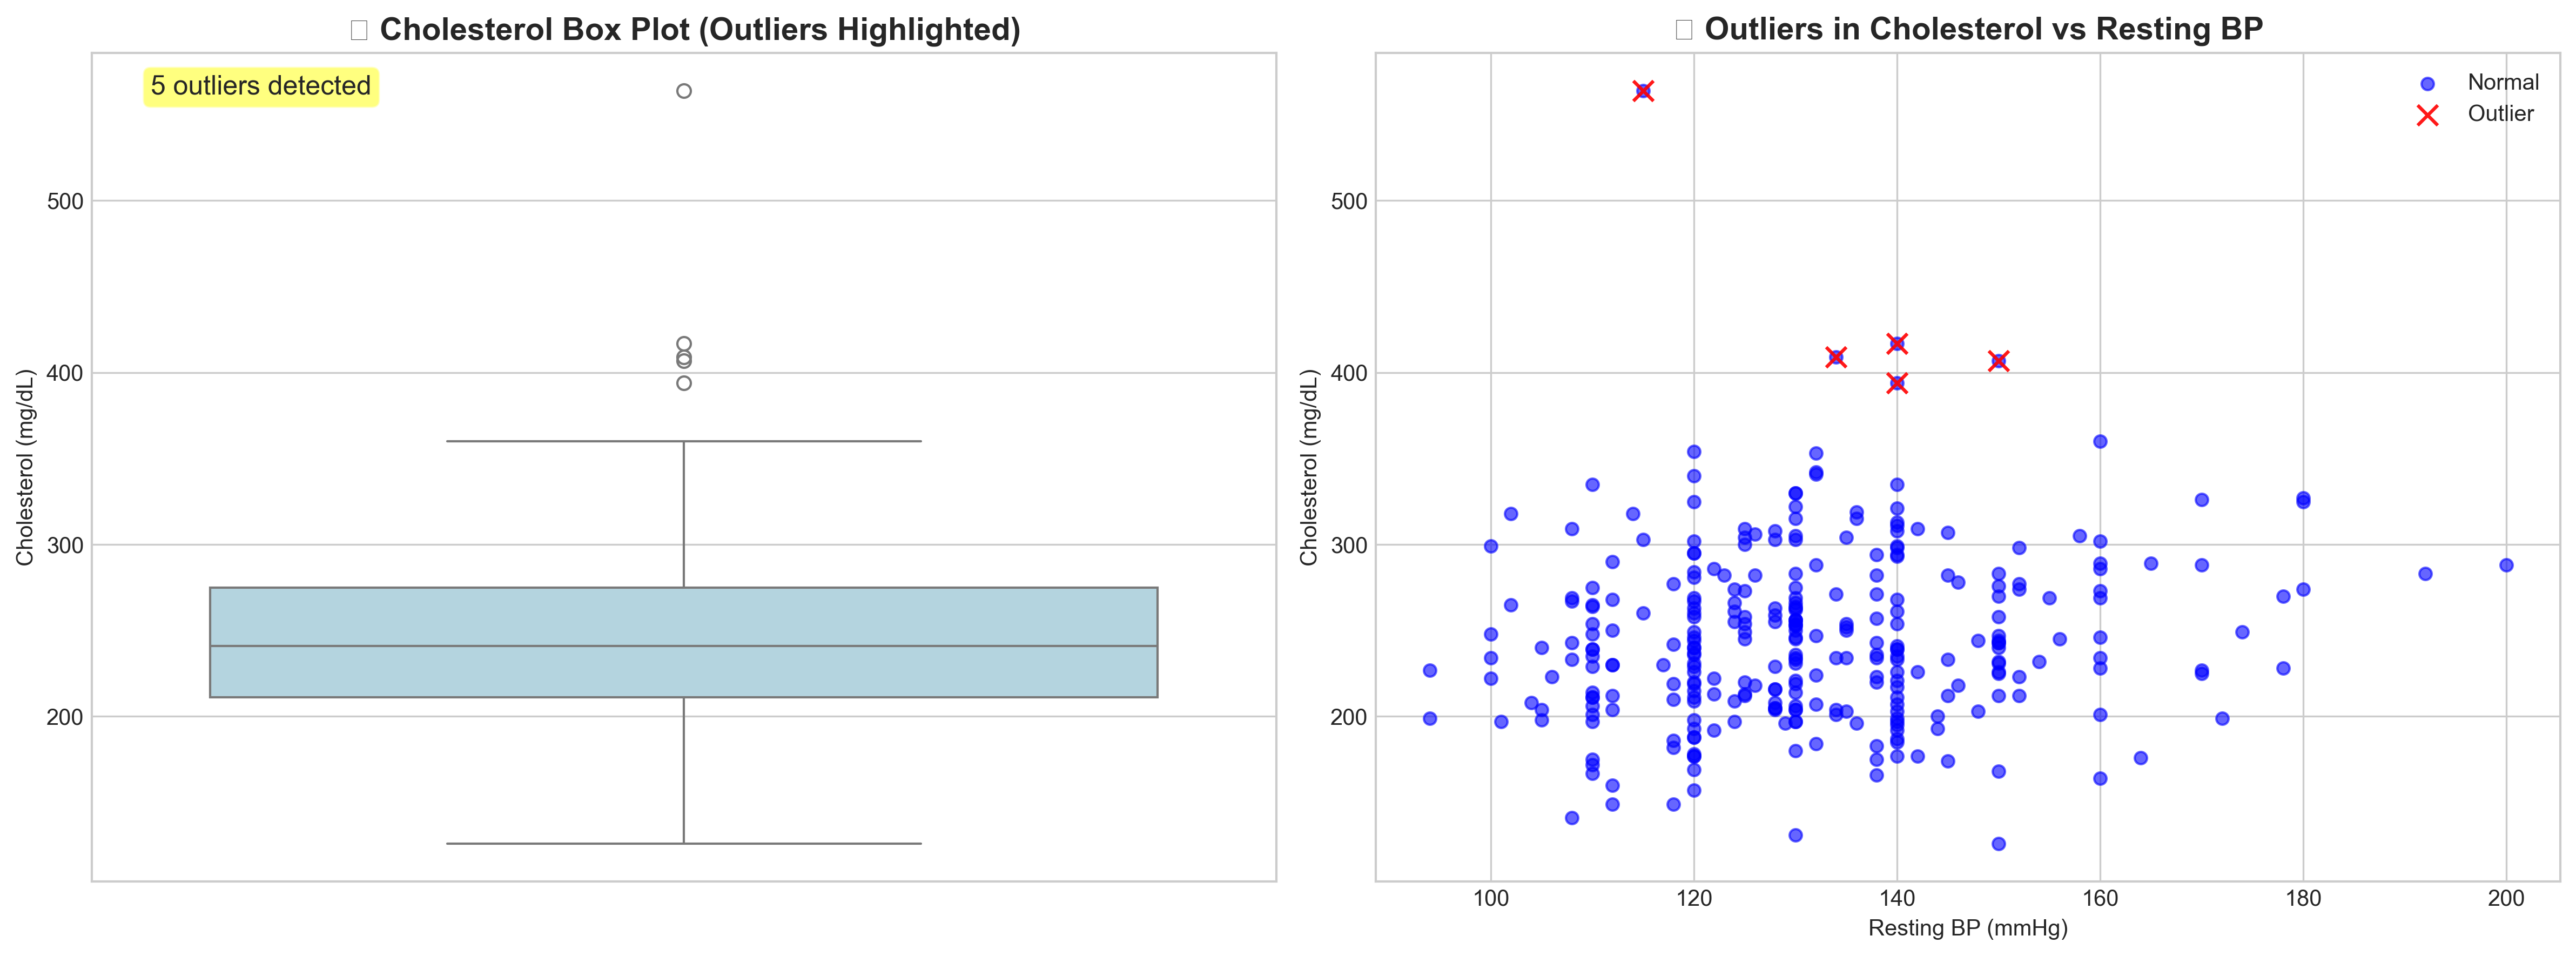


 **Characteristics of Outliers:**
   Average age for outliers: 62.60 years
   Average cholesterol for outliers: 438.20 mg/dL
   Average resting BP for outliers: 135.80 mmHg

   Outlier distribution by category:
   sex: {0.0: 5}
   cp: {4.0: 3, 3.0: 2}
   exang: {0.0: 4, 1.0: 1}
   target: {0: 3, 1: 2}


In [48]:
print("="*60)
print("OUTLIER DETECTION & ANALYSIS (CHOLESTEROL)")
print("="*60)

# 10.1 Identify outliers using IQR method
Q1 = df['chol'].quantile(0.25)
Q3 = df['chol'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['chol'] < lower_bound) | (df['chol'] > upper_bound)]

print(f"\n📊 Cholesterol Outliers (IQR Method):")
print(f"   Q1: {Q1:.2f}")
print(f"   Q3: {Q3:.2f}")
print(f"   IQR: {IQR:.2f}")
print(f"   Lower bound: {lower_bound:.2f}")
print(f"   Upper bound: {upper_bound:.2f}")
print(f"   Number of outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

# 10.2 Visualize outliers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Box plot highlighting outliers
sns.boxplot(data=df, y='chol', ax=ax1, color='lightblue')
ax1.set_title('📦 Cholesterol Box Plot (Outliers Highlighted)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Cholesterol (mg/dL)')
ax1.text(0.05, 0.95, f'{len(outliers)} outliers detected', transform=ax1.transAxes, 
         fontsize=12, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# Scatter plot of outliers (chol vs trestbps)
ax2.scatter(df['trestbps'], df['chol'], alpha=0.6, s=30, color='blue', label='Normal')
ax2.scatter(outliers['trestbps'], outliers['chol'], alpha=0.9, s=80, color='red', label='Outlier', marker='x')
ax2.set_title('💉 Outliers in Cholesterol vs Resting BP', fontsize=14, fontweight='bold')
ax2.set_xlabel('Resting BP (mmHg)')
ax2.set_ylabel('Cholesterol (mg/dL)')
ax2.legend()

plt.tight_layout()
plt.show()

# 10.3 Characteristics of outliers
print(f"\n **Characteristics of Outliers:**")
print(f"   Average age for outliers: {outliers['age'].mean():.2f} years")
print(f"   Average cholesterol for outliers: {outliers['chol'].mean():.2f} mg/dL")
print(f"   Average resting BP for outliers: {outliers['trestbps'].mean():.2f} mmHg")
print(f"\n   Outlier distribution by category:")
for col in ['sex', 'cp', 'exang', 'target']:
    print(f"   {col}: {outliers[col].value_counts().to_dict()}")


# 9. **Advanced Insights: Tip Percentage Ranges**

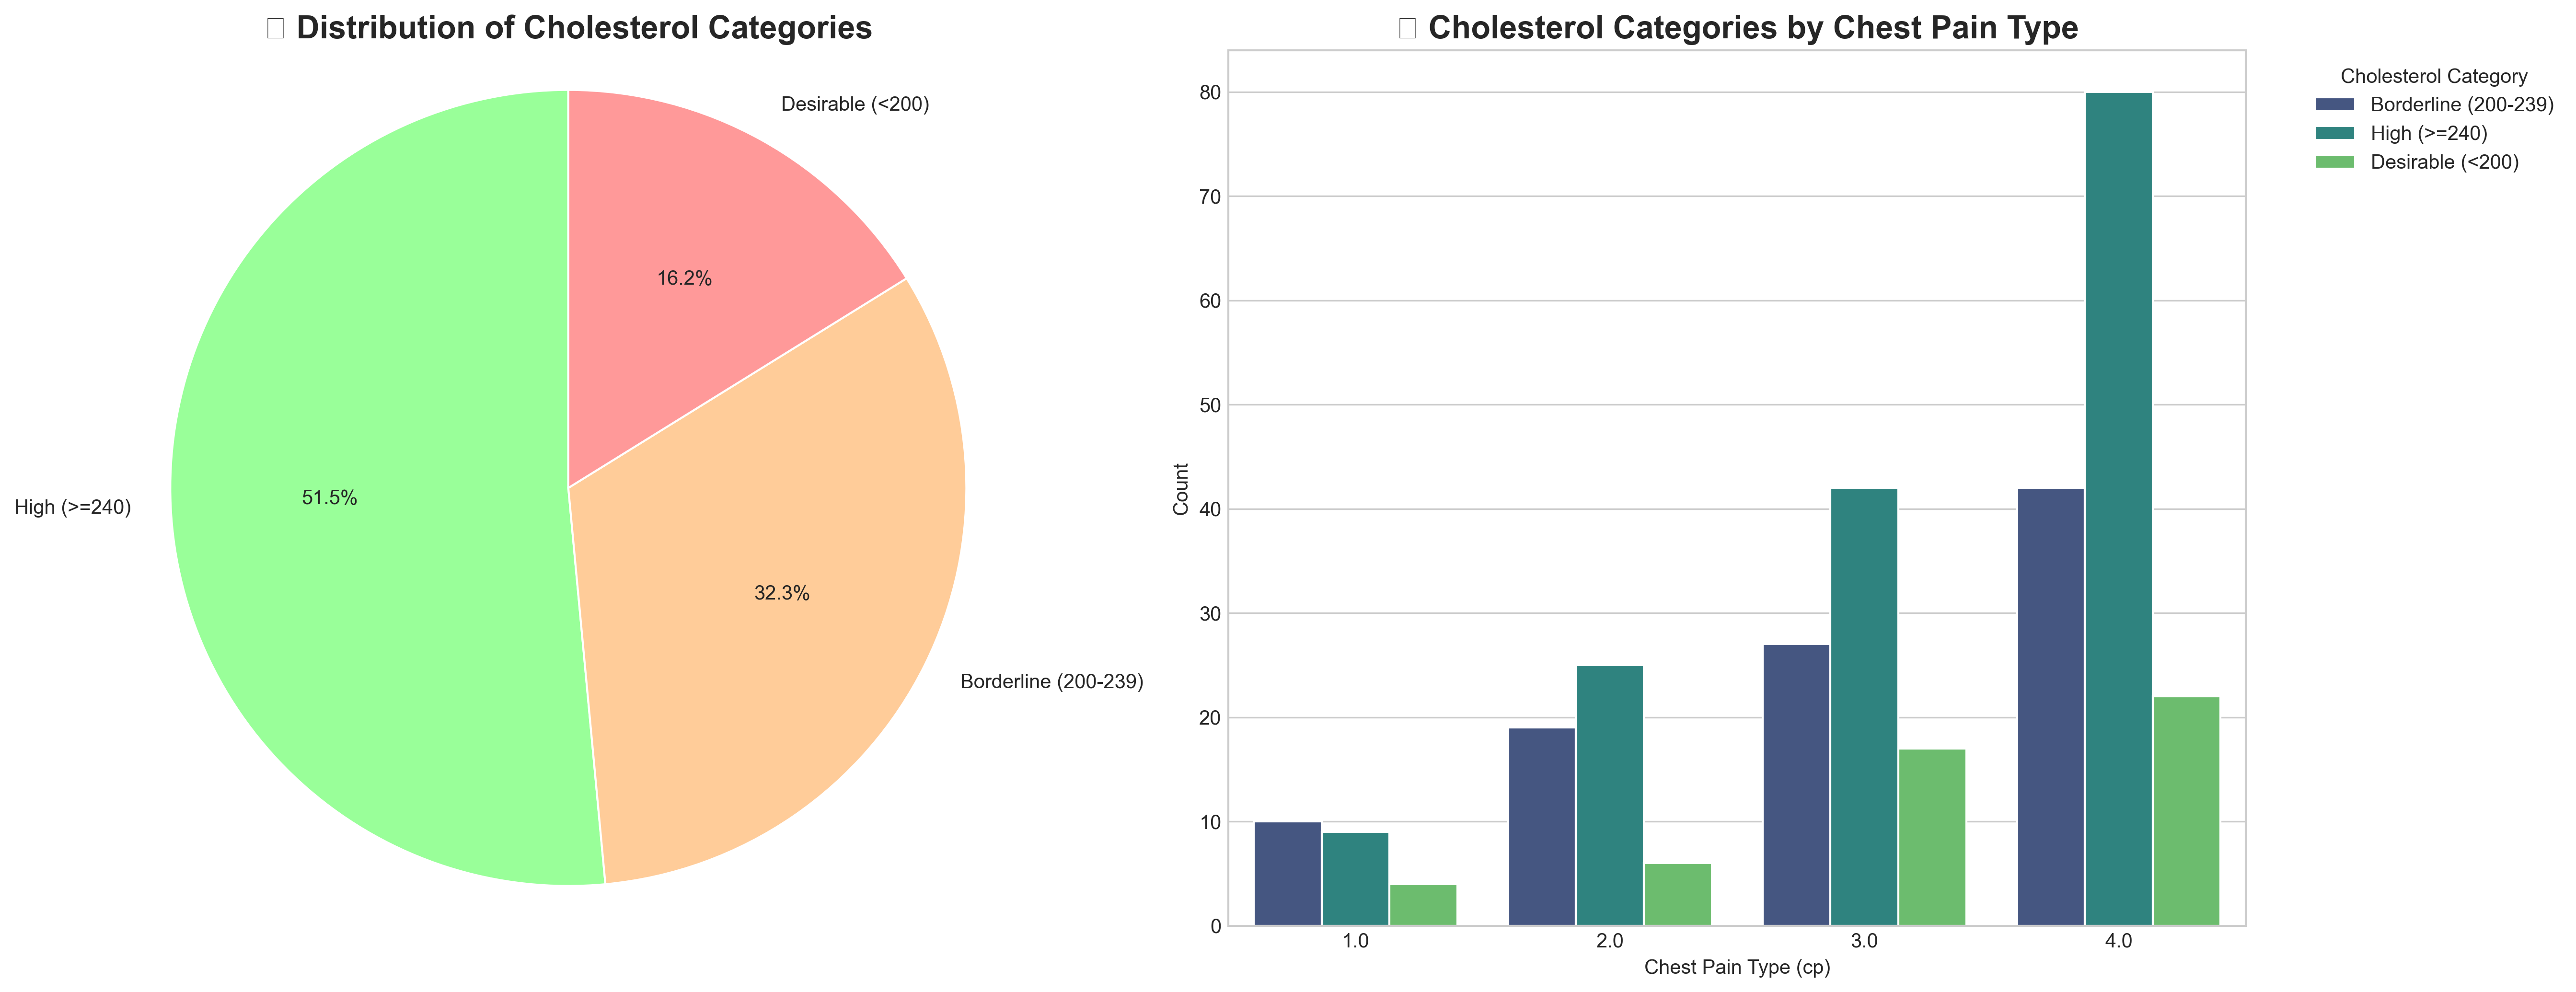

💡 **Cholesterol Category Insights:**
   Borderline (200-239): 98 patients (32.3%)
   High (>=240): 156 patients (51.5%)
   Desirable (<200): 49 patients (16.2%)


In [49]:
# 11.1 Create cholesterol categories
def categorize_chol(chol):
    if chol < 200:
        return "Desirable (<200)"
    elif chol < 240:
        return "Borderline (200-239)"
    else:
        return "High (>=240)"

df['chol_category'] = df['chol'].apply(categorize_chol)

# Visualize cholesterol categories
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Pie chart of cholesterol categories
category_counts = df['chol_category'].value_counts()
colors = ['#99ff99', '#ffcc99', '#ff9999']
ax1.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
ax1.set_title('🥧 Distribution of Cholesterol Categories', fontsize=16, fontweight='bold')
ax1.axis('equal')

# Bar plot by chest pain type
sns.countplot(data=df, x='cp', hue='chol_category', ax=ax2, palette='viridis')
ax2.set_title('📊 Cholesterol Categories by Chest Pain Type', fontsize=16, fontweight='bold')
ax2.set_xlabel('Chest Pain Type (cp)')
ax2.set_ylabel('Count')
ax2.legend(title='Cholesterol Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

print("💡 **Cholesterol Category Insights:**")
for category in df['chol_category'].unique():
    count = len(df[df['chol_category'] == category])
    pct = count / len(df) * 100
    print(f"   {category}: {count} patients ({pct:.1f}%)")


 # 10. **Modeling using Regression Analysis**

 SIMPLE PREDICTIVE MODEL: Max Heart Rate Prediction

 Model Performance:
   R² Score: 0.249
   RMSE: 19.86
   Average Max Heart Rate: 149.51

 Coefficients:
   age: -0.921
   sex: -1.343
   trestbps: 0.135
   chol: 0.034
   oldpeak: -5.306
   ca: -1.718
   Intercept: 181.36


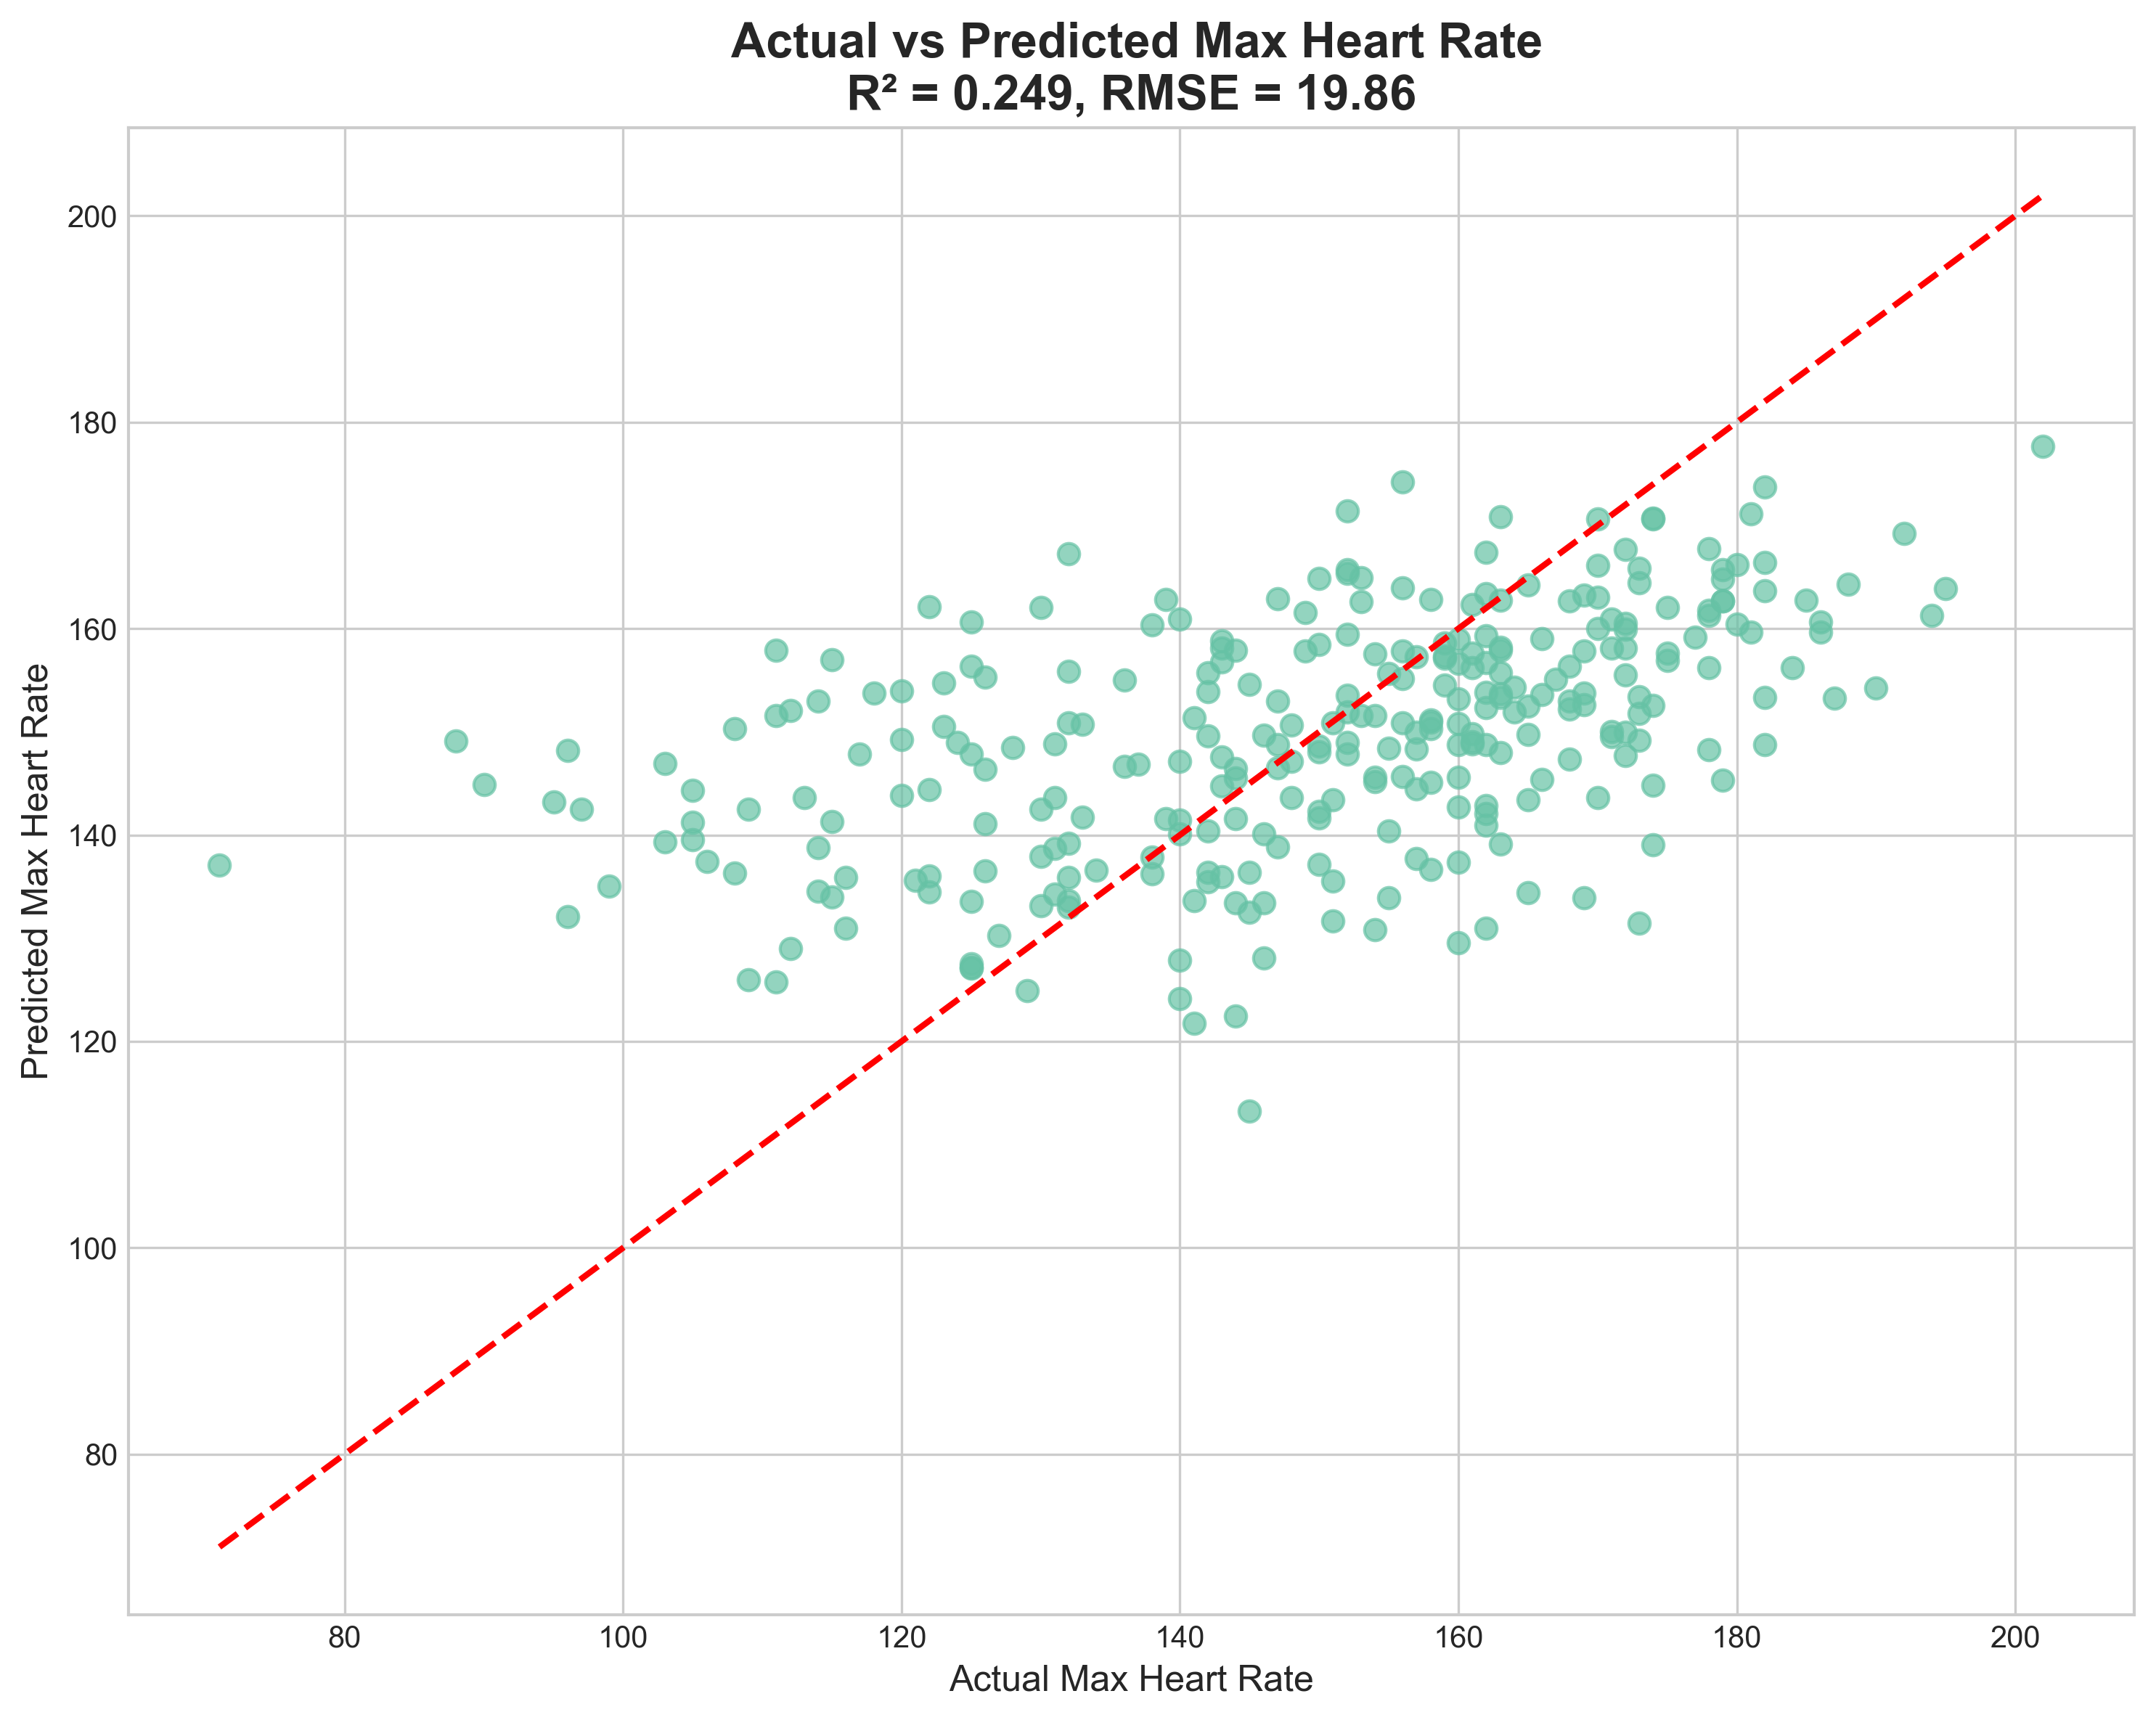

In [53]:
# 13. Simple Linear Regression: Predicting Max Heart Rate (thalach)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

print("=" * 60)
print(" SIMPLE PREDICTIVE MODEL: Max Heart Rate Prediction")
print("=" * 60)

# Select required columns
model_df = df[['age', 'sex', 'trestbps', 'chol', 'oldpeak', 'ca', 'thalach']].copy()

# Convert to numeric and handle invalid values
for col in model_df.columns:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

# Drop rows with missing values
model_df = model_df.dropna()

# Features and target
X = model_df[['age', 'sex', 'trestbps', 'chol', 'oldpeak', 'ca']]
y = model_df['thalach']

# Fit model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# Metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"\n Model Performance:")
print(f"   R² Score: {r2:.3f}")
print(f"   RMSE: {rmse:.2f}")
print(f"   Average Max Heart Rate: {y.mean():.2f}")

# Coefficients
print(f"\n Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"   {feature}: {coef:.3f}")
print(f"   Intercept: {model.intercept_:.2f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(y, y_pred, alpha=0.7, s=50)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)

ax.set_title(
    f' Actual vs Predicted Max Heart Rate\nR² = {r2:.3f}, RMSE = {rmse:.2f}',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Actual Max Heart Rate', fontsize=12)
ax.set_ylabel('Predicted Max Heart Rate', fontsize=12)

plt.tight_layout()
plt.show()

**Model Insight:** 

Age, resting BP, cholesterol, oldpeak, and number of major vessels explain part of the variability in max heart rate achieved during exercise, but other factors (fitness, medications, genetics) also play a role.

# 11. **Interactive Plotly Visualization for Heart Disease Data**

In [54]:
import plotly.express as px

# Interactive Plotly Visualization for Heart Disease Data
fig = px.scatter(df, x='age', y='thalach', color='sex', size='chol', 
                 hover_data=['cp', 'trestbps', 'oldpeak', 'target'],
                 color_continuous_scale='Viridis',
                 title=' Interactive: Max Heart Rate vs Age (Size = Cholesterol, Color = Sex)')

fig.update_layout(
    font=dict(size=12),
    title_font=dict(size=16, family="serif"),
    xaxis_title='Age',
    yaxis_title='Max Heart Rate Achieved (thalach)',
    coloraxis_colorbar=dict(title='Sex')
)

fig.show()

# 12. **Final Summary and Key Findings**


- Heart disease cases slightly dominate the dataset.
- Age, exercise-induced angina, ST depression, and maximum heart rate show strong associations with heart disease.
- Cholesterol and blood pressure exhibit high variability with weaker direct effects.
- Results support the need for predictive modeling in future work.
- Oldpeak shows strong statistical significance across chest pain types
- Oldpeak differs significantly between heart disease and non heart disease patients
- Patients with heart disease have lower mean Oldpeak values
- Chest pain type has a clear impact on exercise induced ST depression
- Gender based and exercise induced angina comparisons are not reliable due to missing values
- Overall, Oldpeak is a key indicator for heart disease analysis and modeling

**Conclusion:** The analysis highlights key clinical indicators useful for heart disease risk assessment.


------